# Analysis Notebook

# Setup

In [ ]:
#| label: setup
#| include: false
packages <- c("emmeans","DescTools", "coin","XNomial","brms","nnet","lme4","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

# Build DF’s into long format

In [ ]:
#| label: build_dfs

df_exp1_single_long <- df_exp1_single_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = matches("_(l0|l1)$"),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    reef_type     = factor(reef, levels = REEF_LEVELS)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, size_mm1, weight_g1, date, stage, t_leave_s, t_l0_s, location_code, reef_type,legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp1_single_long, "df_exp1_single_long.csv")

# EXP 2 – Group reefs (long)
df_exp2_group_long <- df_exp2_group_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1,
      reef_l0, reef_l1,legs_l0, claws_l0, antenna_l0,legs_l1, claws_l1, antenna_l1), names_to = c(".value", "stage"), names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage          = toupper(stage),
    location_code  = factor(toupper(location), levels = LOC_LEVELS),
    reef_type      = factor(reef, levels = REEF_LEVELS),
    size_mm_stage  = if_else(stage == "L0", size_mm1, size_mm2, NA_real_),
    weight_g_stage = if_else(stage == "L0", weight_g1, weight_g2, NA_real_)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date,stage, t_leave_s, t_l0_s, location_code, reef_type,legs, claws, antenna, size_mm_stage, weight_g_stage,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp2_group_long, "df_exp2_group_long.csv")


# EXP 3 – Stone / wood (long)
df_exp3_woodstone_long <- df_exp3_woodstone_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1, reef_l0, reef_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS3),
    reef_type     = factor(reef, levels = REEF_LEVELS3)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, reef_type, size_mm1, weight_g1, legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2, notes_exp, notes_koura)

write_out(df_exp3_woodstone_long, "df_exp3_woodstone_long.csv")


# EXP 4 – Bricks (long)
df_exp4_brick_long <- df_exp4_brick_raw %>%
  mutate(location_l1 = l1) %>%
  pivot_longer(cols = c(location_l1, reef_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    reef_type     = factor(reef, levels = REEF_LEVELS4)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, reef_type,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp4_brick_long, "df_exp4_brick_long.csv")

# Exp 1 Single koura

## Exp 1 Statistic

In [ ]:
#| label: stats-exp1
#| tbl-cap: "Exp 1 statistical results"

# RQ 1: Is there a statistical difference between reef type in L1?
# RQ 2: Is there a preference within each sex?
# RQ 3: Does reef type differ between sex?
# RQ 4: Did reef type use shift directionally between L0 and L1?

df1 <- df_exp1_single_long %>%
  mutate(
    reef_type     = factor(reef_type),
    stage         = factor(stage, levels = c("L0", "L1")),
    sex           = factor(sex),
    size_class    = factor(size_class),
    location_code = factor(location_code),
    tank          = factor(tank),
    round         = factor(round),
    koura_id      = factor(koura_id),
    size_mm1      = as.numeric(size_mm1),
    weight_g1     = as.numeric(weight_g1)) %>%
  filter(!is.na(reef_type))

df1_L1 <- df1 %>% filter(stage == "L1" , reef_type != "TankWall") %>%
  mutate(reef_type = droplevels(reef_type))

pct_wood_overall <- round(mean(df1_L1$reef_type == "WoodLog") * 100)
pct_wood_male    <- round(mean(df1_L1$reef_type[df1_L1$sex == "M"] == "WoodLog") * 100)
pct_wood_female  <- round(mean(df1_L1$reef_type[df1_L1$sex == "F"] == "WoodLog") * 100)

# RQ1 — Reef type preference at L1
tab1_L1 <- table(df1_L1$reef_type)
tab1_L1_nz <- tab1_L1[tab1_L1 > 0]

xmulti1 <- XNomial::xmulti(obs  = as.numeric(tab1_L1_nz), expr = rep(sum(tab1_L1_nz) / length(tab1_L1_nz), length(tab1_L1_nz)))


P value (LLR) = 1.57e-05


P value (LLR) = 0.09743


P value (LLR) = 5.454e-05

## Exp 1 figure

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

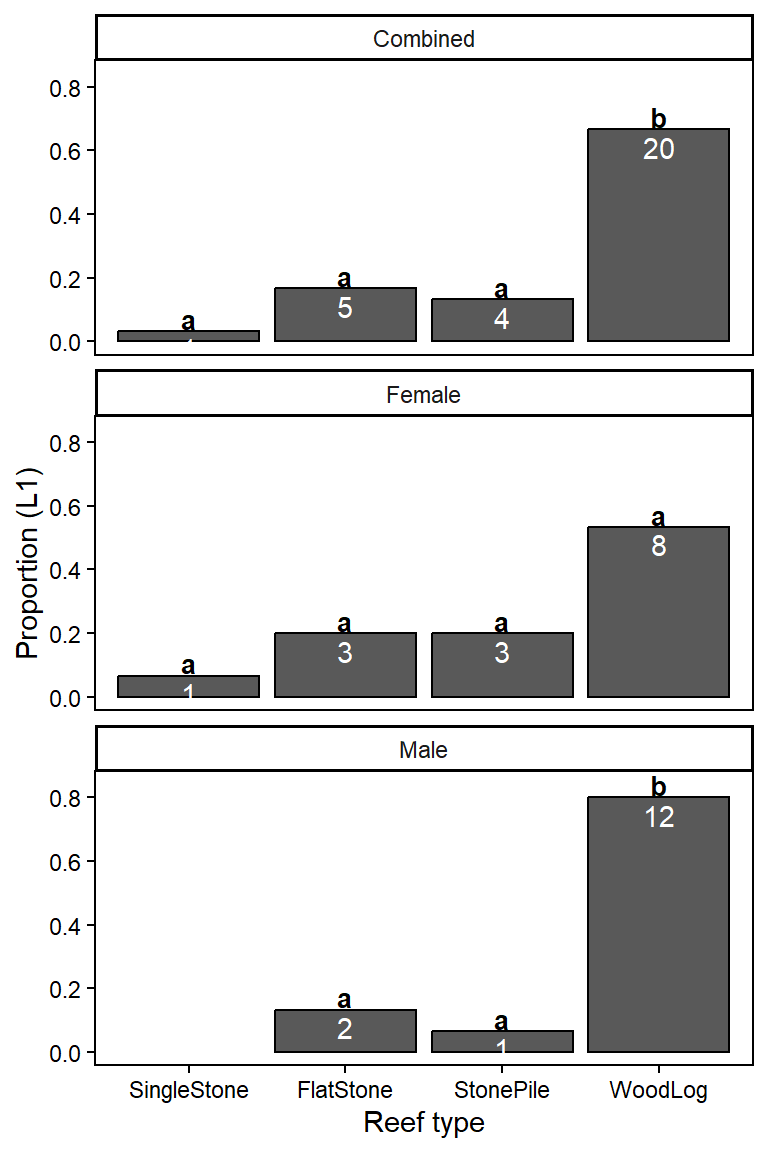

In [ ]:
#| label: fig-exp1
#| fig-width: 4
#| fig-height: 6
#| fig-cap: "."

exp1_reef_combined <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, reef_type, name = "n") %>%
  group_by(stage) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef() %>%
  mutate(panel = "Combined")

exp1_reef_bysex <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, reef_type, sex, name = "n") %>%
  group_by(stage, sex) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef() %>%
  mutate(panel = dplyr::recode(sex, F = "Female", M = "Male")) %>%
  select(-sex)

lab_panel1 <- c(Combined = "Combined", Female = "Female", Male = "Male")

exp1_reef_all <- dplyr::bind_rows(exp1_reef_combined, exp1_reef_bysex)

exp1_reef_letters <- exp1_reef_all %>%
  relevel_reef() %>%
  filter(stage == "L1") %>%
  left_join(cld_all1, by = c("stage", "panel", "reef_type"))

Exp1_reef_p <- exp1_reef_all %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = exp1_reef_letters,aes(y = prop + 0.04, label = cld_letter), size  = 3.5, fontface = "bold") +
  facet_wrap(~ panel, ncol = 1, labeller = labeller(panel = lab_panel1)) +
  labs(x = "Reef type", y = "Proportion (L1)")

ggsave(Exp1_reef_p, file = file.path(out_dir, "fig-exp1.png"), width = 4, height = 6, dpi = 300)

## Exp 1 II

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

...

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

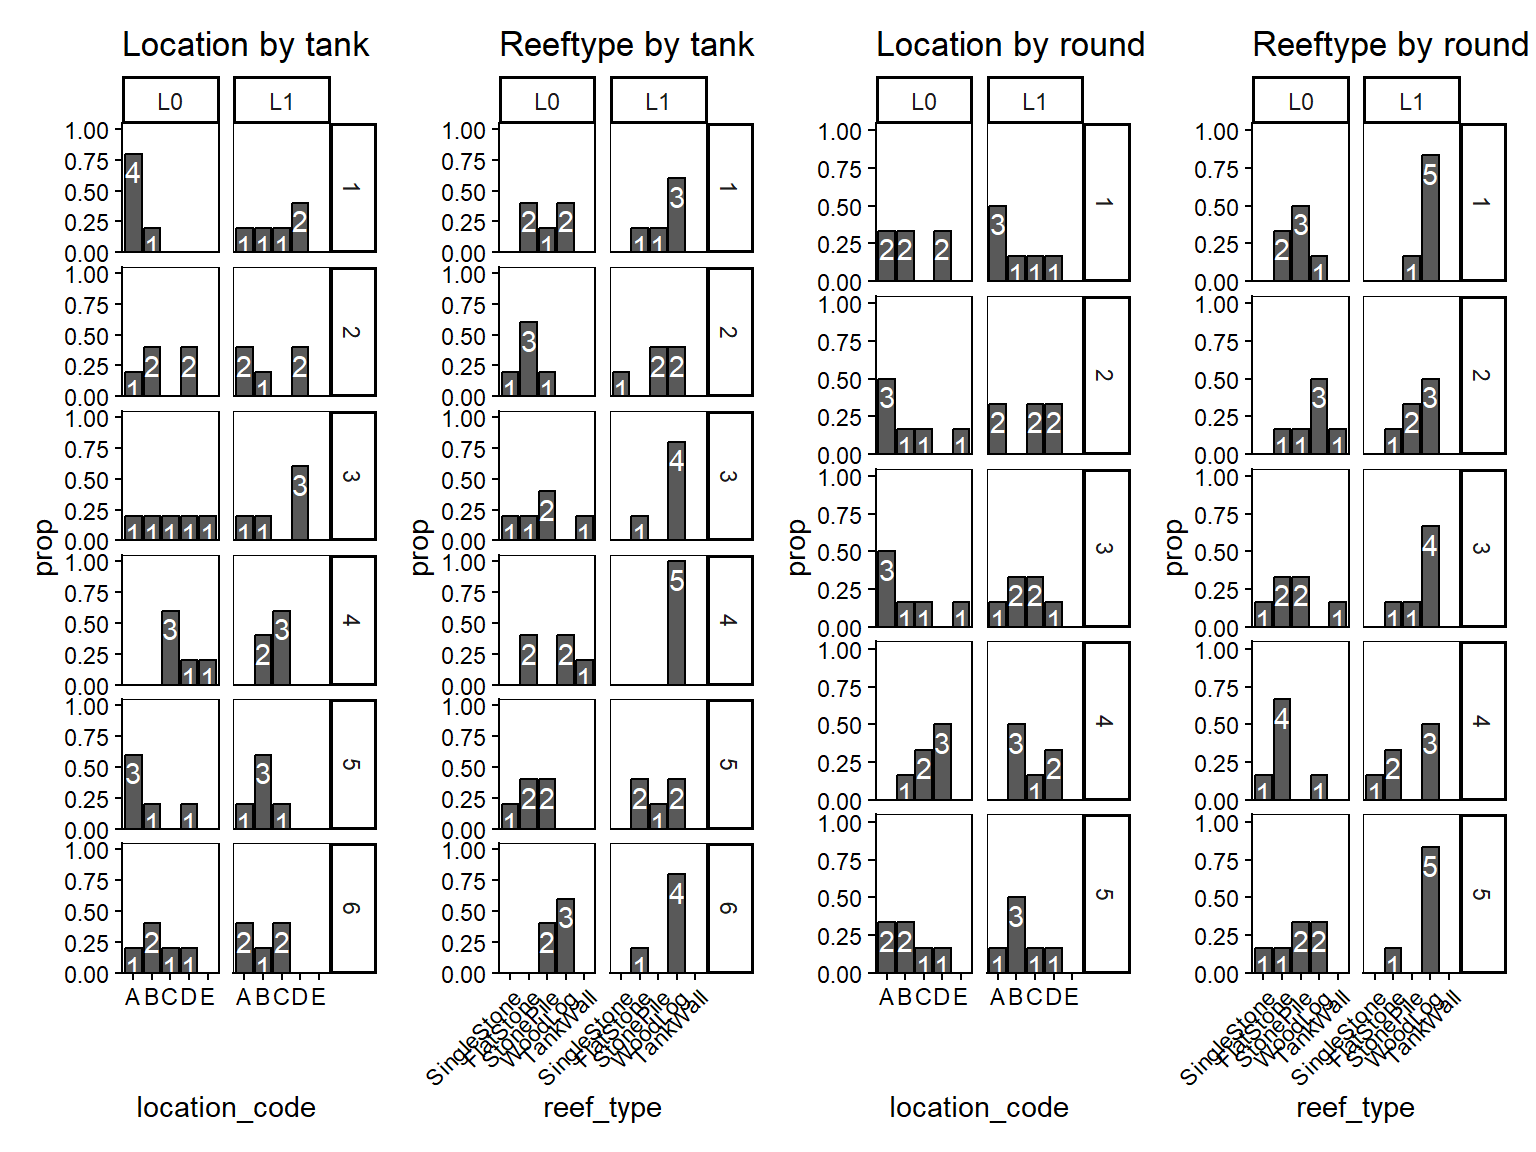

In [ ]:
#| label: fig-exp1-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; rows = facetvar, cols = stage; fixed y-scale across all plots
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title) +
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp1_loc    <- mk_props(df_exp1_single_long, location_code, tank)
  exp1_round  <- mk_props(df_exp1_single_long, location_code, round)
  exp1_loc2   <- mk_props(df_exp1_single_long, reef_type,     tank)
  exp1_round2 <- mk_props(df_exp1_single_long, reef_type,     round)

  # plots
  p_exp1_loc    <- mk_bar(exp1_loc,   location_code, tank,  "Location by tank")
  p_exp1_round  <- mk_bar(exp1_round, location_code, round, "Location by round")
  p_exp1_loc2   <- mk_bar(exp1_loc2,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp1_round2 <- mk_bar(exp1_round2,reef_type,     round, "Reeftype by round", reef = TRUE)

  loc_round_plots_exp1 <<- p_exp1_loc + p_exp1_loc2 + p_exp1_round + p_exp1_round2 +
    patchwork::plot_layout(ncol = 4)
}))
loc_round_plots_exp1

## Exp 1 III

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

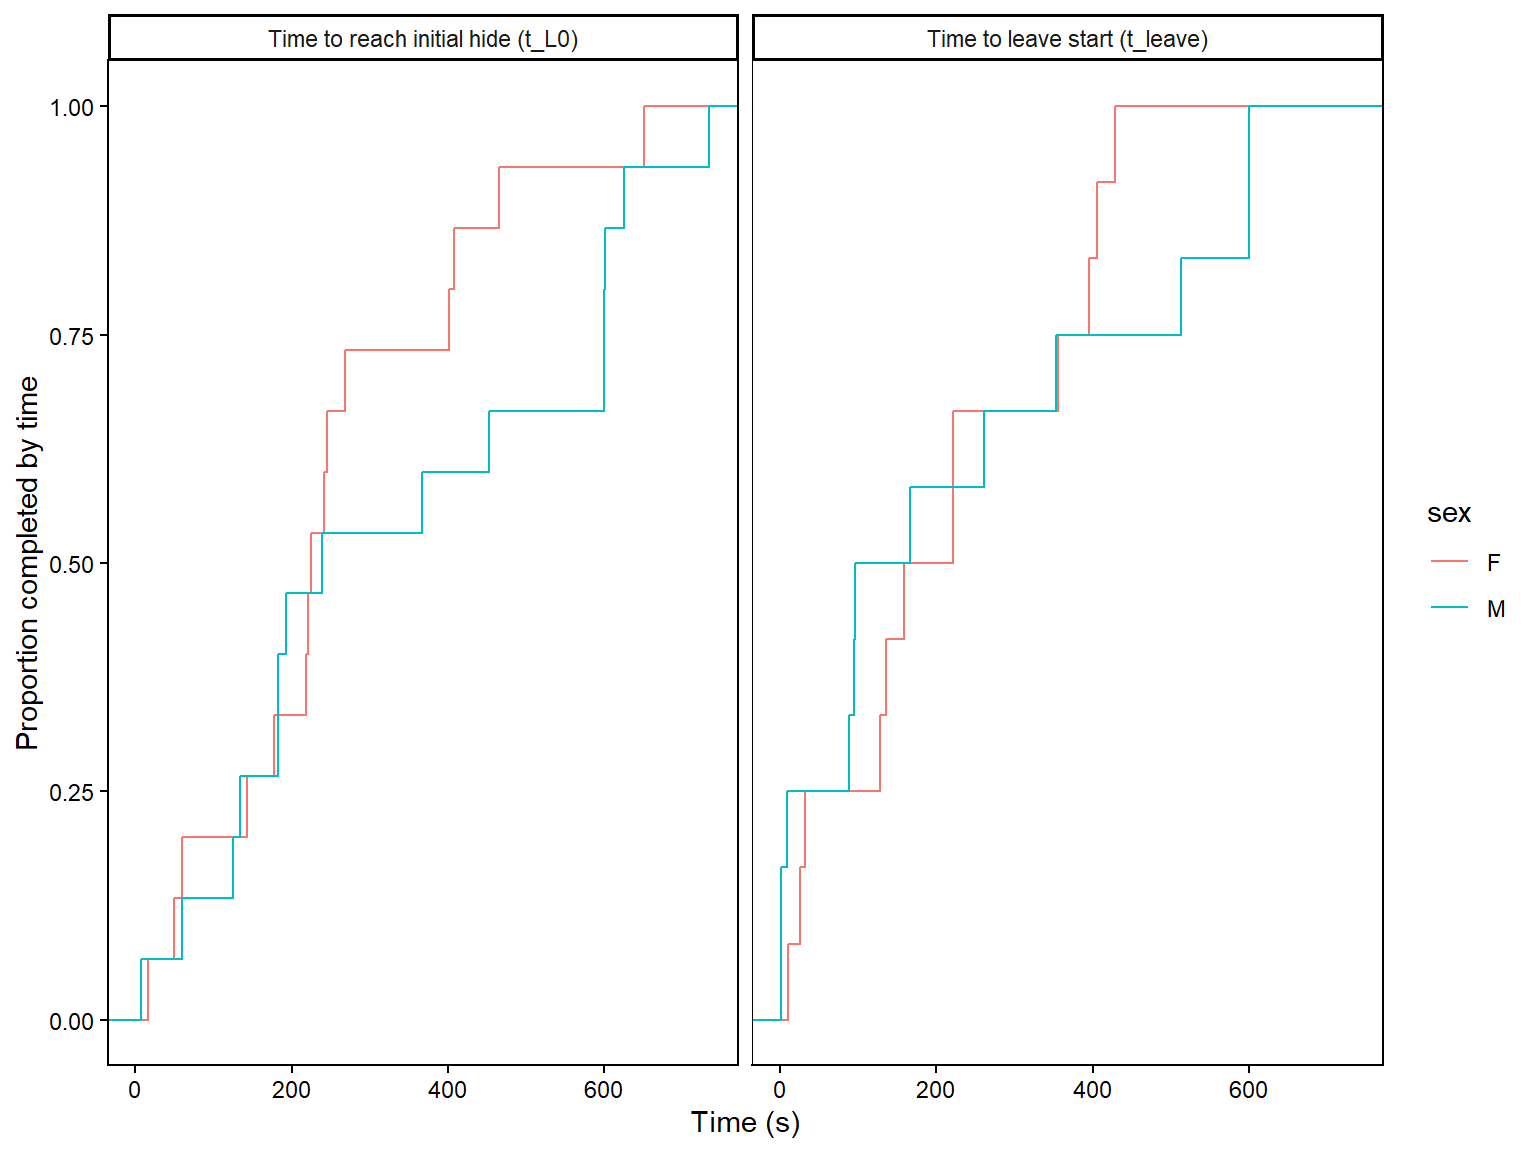

In [ ]:
#| label: fig-exp1-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp1_pairs <- df_exp1_single_long %>%
  dplyr::filter(stage %in% c("L0","L1")) %>%
  dplyr::select(koura_id, tank, round, size_class, sex, stage,location_code, reef_type, t_leave_s, t_l0_s) %>%
  dplyr::mutate(
    location_code = forcats::fct_drop(factor(location_code, levels = LOC_LEVELS)),
    reef_type     = forcats::fct_drop(factor(reef_type,     levels = REEF_LEVELS)),
    t_leave_s     = suppressWarnings(as.numeric(t_leave_s)),
    t_l0_s        = suppressWarnings(as.numeric(t_l0_s))) %>%
  tidyr::pivot_wider(names_from = stage,values_from = c(location_code, reef_type, t_leave_s, t_l0_s),names_sep = "_")

activity_df <- exp1_pairs %>%
  dplyr::transmute(koura_id, tank, round, size_class, sex, time_to_leave = t_leave_s_L0, time_at_L0 = t_l0_s_L0) 

activity_long <- activity_df %>%
  mutate(
    time_to_leave = suppressWarnings(as.numeric(time_to_leave)),time_at_L0    = suppressWarnings(as.numeric(time_at_L0))) %>%
  pivot_longer(c(time_to_leave, time_at_L0), names_to = "metric", values_to = "time") %>%
  filter(!is.na(time), time >= 0)

lab_metric <- c(time_to_leave = "Time to leave start (t_leave)",
                time_at_L0    = "Time to reach initial hide (t_L0)")

act_exp1_p <- ggplot(activity_long, aes(time, col=sex)) +
  stat_ecdf(geom = "step") +
  facet_grid( ~ metric, labeller = labeller(metric = lab_metric)) +
  labs(x = "Time (s)", y = "Proportion completed by time")

act_exp1_p

# Exp 2 Group koura

## Exp 2 Statistic

In [ ]:
#| label: stats-exp2
#| tbl-cap: "..."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect reef preference?            (brms categorical)
# RQ 3: Which reef is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df2 <- df_exp2_group_long %>%
  mutate(
    reef_type  = factor(reef_type),
    stage      = factor(stage, levels = c("L0", "L1")),
    sex        = factor(sex),
    size_class = factor(size_class, levels = c("S", "M", "L")),
    location_code = factor(location_code),
    tank       = factor(tank),
    round      = factor(round),
    group_id   = factor(group_id),
    koura_id   = factor(koura_id)) %>%
  filter(!is.na(reef_type))

# RQ1 — Overall reef preference at group level
df2_grp <- df2 %>%
  filter(stage == "L1") %>%
  count(group_id, round, reef_type) %>%
  complete(group_id, round, reef_type, fill = list(n = 0)) %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each reef type differs from uniform (0.25)
wilcox_flat  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "FlatStone"],  mu = 0.25, exact = FALSE)
wilcox_pile  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "StonePile"],  mu = 0.25, exact = FALSE)
wilcox_wood  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "WoodLog"],    mu = 0.25, exact = FALSE)
wilcox_single <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "SingleStone"], mu = 0.25, exact = FALSE)

p_wilcox2_adjusted <- p.adjust(
  c(p_wilcox_flat   = wilcox_flat$p.value,
    p_wilcox_single = wilcox_single$p.value,
    p_wilcox_pile   = wilcox_pile$p.value,
    p_wilcox_wood   = wilcox_wood$p.value),
  method = "bonferroni")
#p_wilcox2_adjusted

# Extract named values for inline use
p_wilcox2_flat   <- p_wilcox2_adjusted["p_wilcox_flat"]
p_wilcox2_single <- p_wilcox2_adjusted["p_wilcox_single"]
p_wilcox2_pile   <- p_wilcox2_adjusted["p_wilcox_pile"]
p_wilcox2_wood   <- p_wilcox2_adjusted["p_wilcox_wood"]

# Direct comparison FlatStone vs StonePile at group level
fs_props <- df2_grp %>% filter(reef_type == "FlatStone") %>% pull(prop)
sp_props <- df2_grp %>% filter(reef_type == "StonePile") %>% pull(prop)

wilcox_fs_vs_sp <- wilcox.test(fs_props, sp_props, paired = TRUE, exact = FALSE)
p_fs_vs_sp <- wilcox_fs_vs_sp$p.value
#p_fs_vs_sp


# RQ2 — Does size class affect reef preference?
# Model last fit: 2024-10-15
# Delete m2_size_bayes.rds to refit

# Path to saved model
m_path2 <- file.path(der_data_dir, "m_exp2_bayes.rds")

# Only fit if model file doesn't exist
if (!file.exists(m_path2)) {
  m_exp2_bayes <- brm(
    reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data          = df2 %>% filter(stage == "L1"),
    family        = categorical(),
    cores         = 4,
    iter          = 4000,
    open_progress = FALSE,
    control       = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp2_bayes, m_path2)
} else {
  m_exp2_bayes <- readRDS(m_path2)
}

# Diagnostics
nuts_params(m_exp2_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))

  sum(Value)
1          0

 Family: categorical 
  Links: muFlatStone = logit; muStonePile = logit; muWoodLog = logit 
Formula: reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round) 
   Data: df2 %>% filter(stage == "L1") (Number of observations: 180) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 6) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muFlatStone_Intercept)     0.26      0.24     0.01     0.92 1.00     4911
sd(muStonePile_Intercept)     0.33      0.30     0.01     1.09 1.00     4285
sd(muWoodLog_Intercept)       0.46      0.39     0.02     1.44 1.00     3512
                          Tail_ESS
sd(muFlatStone_Intercept)     4371
sd(muStonePile_Intercept)     4639
sd(muWoodLog_Intercept)       4328

~group_id:koura_id (Number of levels: 36) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muFlatStone_Intercept)  

                          Estimate Est.Error       Q2.5      Q97.5
muFlatStone_Intercept    2.7897496 0.8160380  1.3840435  4.5655209
muStonePile_Intercept    2.1490900 0.8769514  0.5783038  4.0618278
muWoodLog_Intercept      1.5934189 1.0138501 -0.3142599  3.7300993
muFlatStone_size_classM -1.7624486 0.9098082 -3.7250837 -0.1063132
muFlatStone_size_classL -0.9887577 0.9516650 -2.9666992  0.7666881
muStonePile_size_classM -1.4384963 0.9478844 -3.4641471  0.2818704
muStonePile_size_classL -0.4412566 0.9814677 -2.5191293  1.3744576
muWoodLog_size_classM   -0.9190254 0.9611542 -2.9744212  0.8526398
muWoodLog_size_classL   -1.1381381 1.0357651 -3.2523160  0.7883138

## Exp 2 table

In [ ]:
#| label: tbl-exp2
#| tbl-cap: "Experiment 2 Bayesian model fixed effects"

fixef(m_exp2_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)

  Parameter                    Mean     SD    2.5%   97.5%
  ------------------------- ------- ------ ------- -------
  muFlatStone_Intercept        2.79   0.82    1.38    4.57
  muStonePile_Intercept        2.15   0.88    0.58    4.06
  muWoodLog_Intercept          1.59   1.01   -0.31    3.73
  muFlatStone_size_classM     -1.76   0.91   -3.73   -0.11
  muFlatStone_size_classL     -0.99   0.95   -2.97    0.77
  muStonePile_size_classM     -1.44   0.95   -3.46    0.28
  muStonePile_size_classL     -0.44   0.98   -2.52    1.37
  muWoodLog_size_classM       -0.92   0.96   -2.97    0.85
  muWoodLog_size_classL       -1.14   1.04   -3.25    0.79


## Exp 2 figure

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

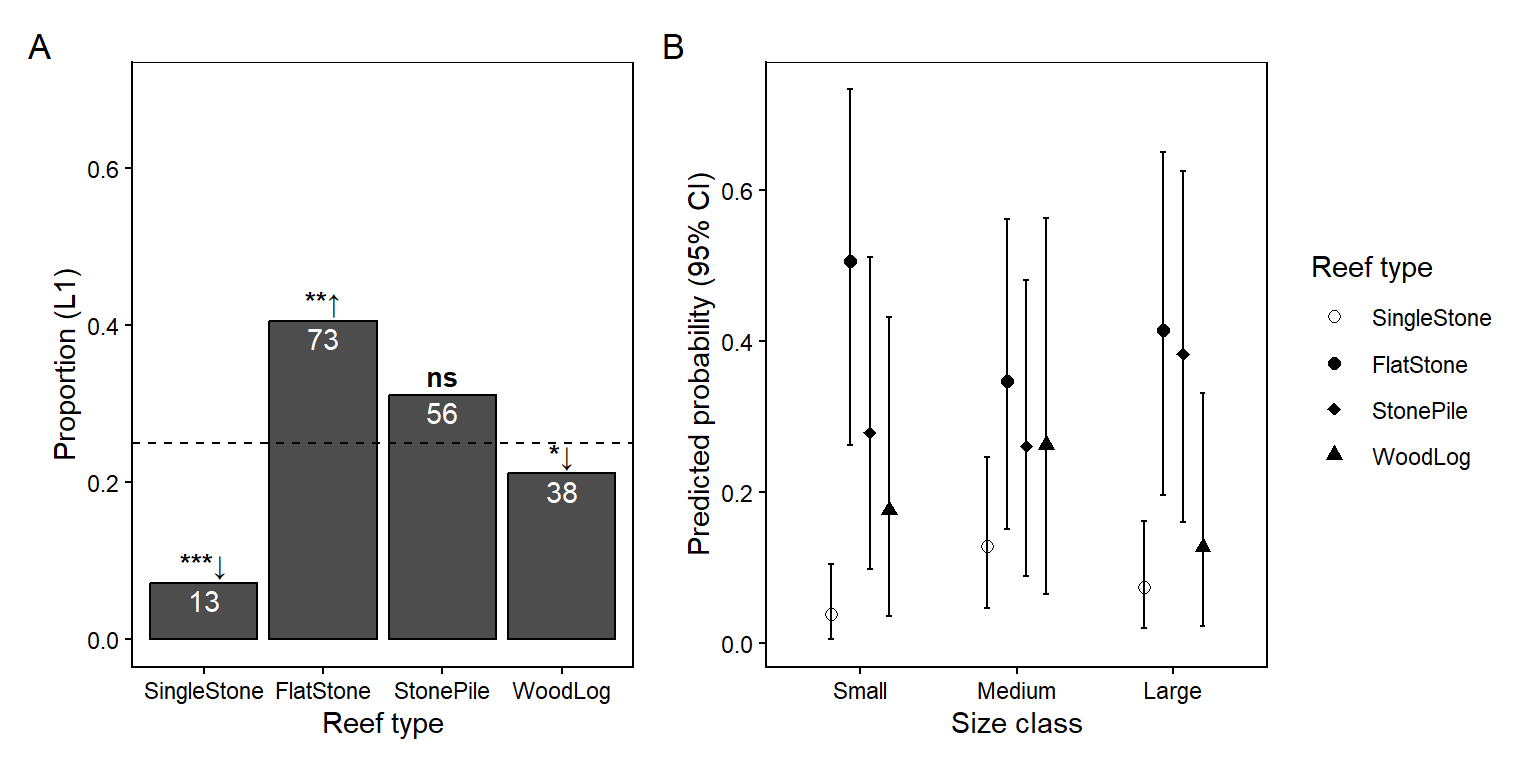

In [ ]:
#| label: fig-exp2
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp2_combined <- df_exp2_group_long %>%
  filter(stage == "L1") %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef() %>%
  mutate(panel = "Combined")

# Wilcoxon significance
ann_wilcox2 <- data.frame(
  reef_type = c("SingleStone", "FlatStone", "StonePile", "WoodLog"),
  label     = c(sig_label(p_wilcox2_adjusted["p_wilcox_single"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_flat"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_pile"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_wood"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS)) %>%
  left_join(exp2_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.025, label = case_when(
           reef_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), reef_type %in% c("SingleStone", "WoodLog") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp2_combined_p <- exp2_combined %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = 0.25, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox2, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.7)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce2_p <- pp_summary2 %>%
  filter(reef_type != "TankWall") %>%
  relevel_reef() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(size_class, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 2, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  scale_x_discrete(labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Size class", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

# Combine plots
Exp2_p <- Exp2_combined_p | ce2_p 

ggsave(Exp2_p, file = file.path(out_dir, "fig-exp2.png"), width = 8, height = 4, dpi = 300)

Exp2_p

## Exp 2 II

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

...

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

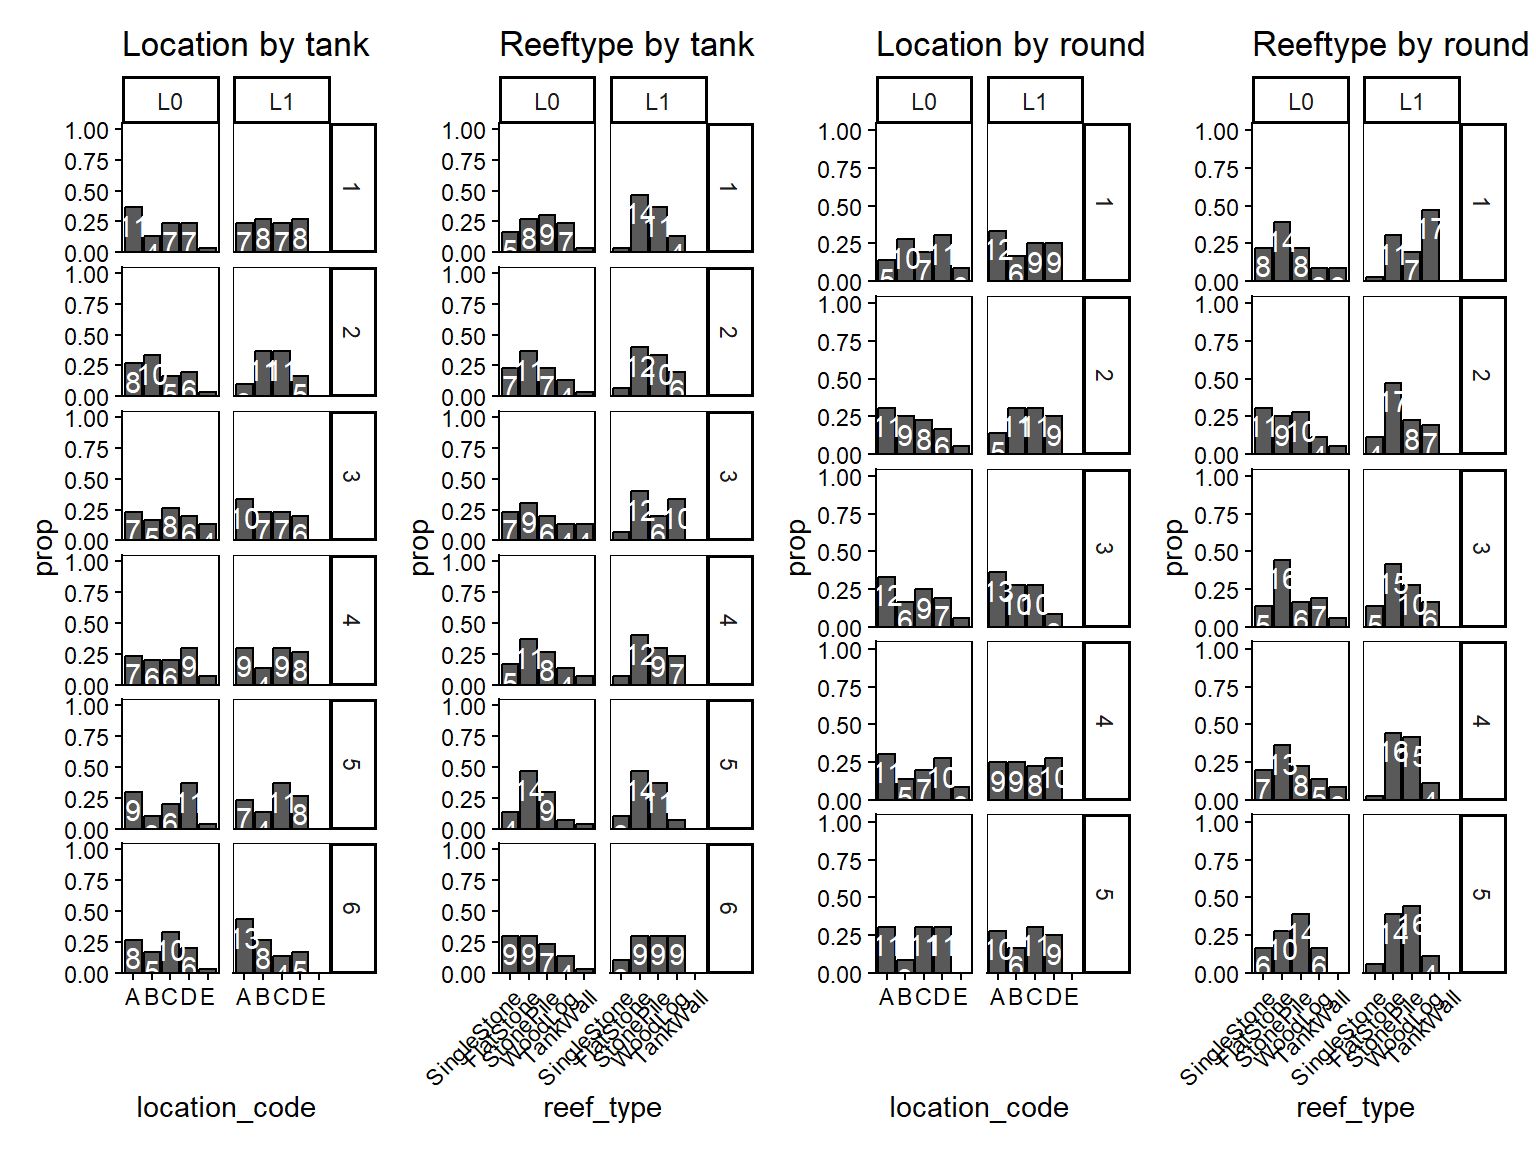

In [ ]:
#| label: fig-exp2-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({

  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp2_loc    <- mk_props(df_exp2_group_long, location_code, tank)
  exp2_round  <- mk_props(df_exp2_group_long, location_code, round)
  exp2_loc2   <- mk_props(df_exp2_group_long, reef_type,     tank)
  exp2_round2 <- mk_props(df_exp2_group_long, reef_type,     round)

  # plots
  p_exp2_loc    <- mk_bar(exp2_loc,   location_code, tank,  "Location by tank")
  p_exp2_round  <- mk_bar(exp2_round, location_code, round, "Location by round")
  p_exp2_loc2   <- mk_bar(exp2_loc2,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp2_round2 <- mk_bar(exp2_round2,reef_type,     round, "Reeftype by round", reef = TRUE)

  loc_round_plots_exp2 <<- p_exp2_loc + p_exp2_loc2 + p_exp2_round + p_exp2_round2 +
    patchwork::plot_layout(ncol = 4)
}))
loc_round_plots_exp2

## Exp 2 III

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

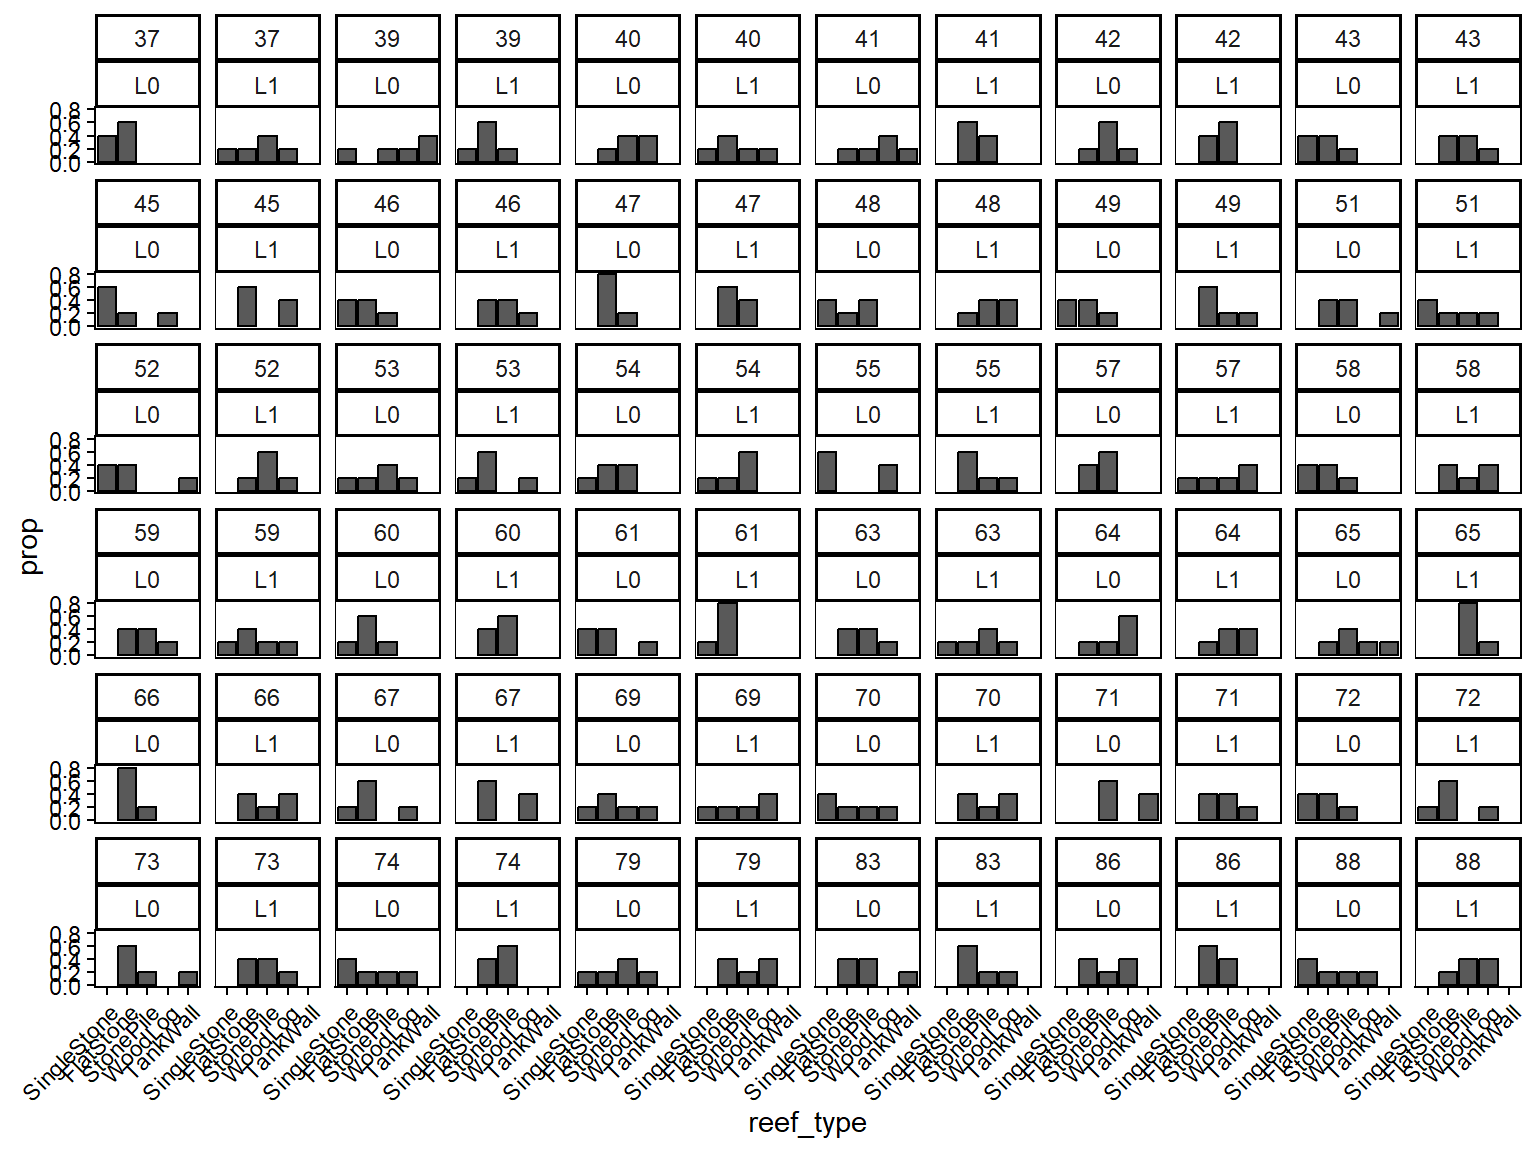

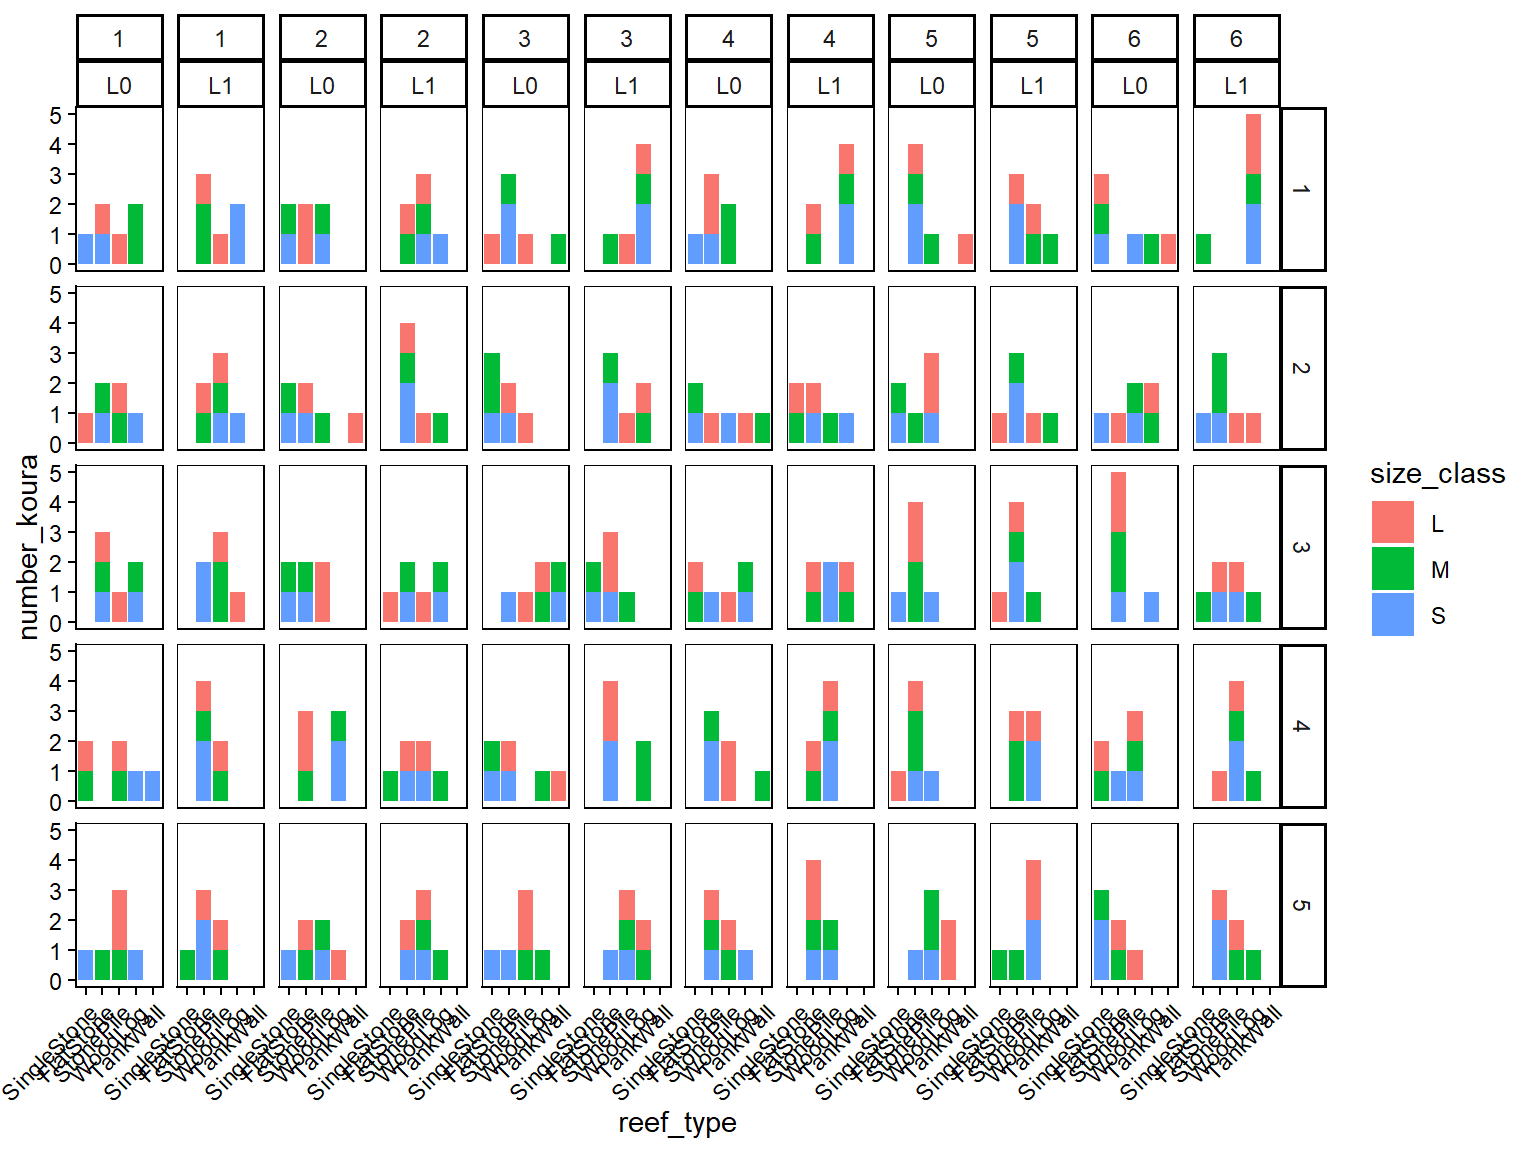

In [ ]:
#| label: fig-exp2-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp2_reef_koura <- df_exp2_group_long %>%
  mutate(stage = toupper(stage)) %>%
  filter(stage %in% c("L0","L1")) %>%
  count(stage, reef_type, koura_id, name = "n") %>%
  group_by(stage, koura_id) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef()

p_exp2_reef_koura <- exp2_reef_koura %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  facet_wrap(koura_id ~ stage, nrow = 6) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_exp2_reef_koura

# Exp 3 Wood vs stone

## Exp 3 Statistic

In [ ]:
#| label: stats-exp3
#| tbl-cap: "."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect reef preference?            (brms categorical)
# RQ 3: Which reef is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df3 <- df_exp3_woodstone_long %>%
  mutate(
    reef_type      = factor(reef_type),
    stage          = factor(stage, levels = c("L0", "L1")),
    sex            = factor(sex), # all male
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(reef_type)) 

df3_L1 <- df3 %>% filter(stage == "L1", !is.na(reef_type), reef_type != "NA")

# RQ1 — Overall reef preference at group level
df3_grp <- df3_L1 %>%
  count(group_id, round, reef_type) %>%
  filter(reef_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

wilcox3_flat  <- wilcox.test(df3_grp$prop[df3_grp$reef_type == "FlatStone"], mu = 0.5, exact = FALSE)
wilcox3_split <- wilcox.test(df3_grp$prop[df3_grp$reef_type == "WoodSplit"], mu = 0.5, exact = FALSE)

p_wilcox3_adjusted <- p.adjust(c(p_wilcox3_flat  = wilcox3_flat$p.value,p_wilcox3_split = wilcox3_split$p.value), method = "bonferroni")

#p_wilcox3_adjusted

# Extract named values for inline use
p_wilcox3_flat  <- p_wilcox3_adjusted["p_wilcox3_flat"]
p_wilcox3_split <- p_wilcox3_adjusted["p_wilcox3_split"]


# RQ2 — Does size class affect reef preference?
# Model last fit: 2024-10-15
# Delete m_exp3_bayes.rds to refit

df3_L1 <- df3_L1 %>% mutate(reef_type = relevel(factor(reef_type), ref = "FlatStone"))

m_path3 <- file.path(der_data_dir, "m_exp3_bayes.rds")

if (!file.exists(m_path3)) {
  m_exp3_bayes <- brm(
    reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data = df3_L1 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp3_bayes, m_path3)
} else {
  m_exp3_bayes <- readRDS(m_path3)
}

# Diagnostics
nuts_params(m_exp3_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))

  sum(Value)
1          0

 Family: categorical 
  Links: muWoodSplit = logit; muTankWall = logit 
Formula: reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round) 
   Data: df3_L1 %>% filter(stage == "L1") (Number of observations: 106) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 6) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muWoodSplit_Intercept)     0.43      0.40     0.01     1.45 1.00     3765
sd(muTankWall_Intercept)      2.31      3.16     0.07     8.19 1.00     5219
                          Tail_ESS
sd(muWoodSplit_Intercept)     3515
sd(muTankWall_Intercept)      3986

~group_id:koura_id (Number of levels: 36) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muWoodSplit_Intercept)     0.73      0.49     0.03     1.86 1.00     2120
sd(muTankWall_Intercept)      2.02      1.96     0.07     6.95 1.00     4481
  

                           Estimate   Est.Error        Q2.5     Q97.5
muWoodSplit_Intercept    -0.3520999   1.0152967   -2.335776  1.828462
muTankWall_Intercept     -4.7597572   7.4513003  -16.454304 10.537060
muWoodSplit_size_classM  -0.2991464   0.6719433   -1.633417  1.012567
muWoodSplit_size_classL  -2.4126224   0.9059028   -4.341521 -0.825144
muTankWall_size_classM  -37.0478202 144.9122677 -225.076450  1.173272
muTankWall_size_classL  -28.6991726  80.4791146 -169.823448  1.012446

[1] 0.671125

[1] 0.99875

## Exp 3 Table

In [ ]:
#| label: tbl-exp3
#| tbl-cap: "Experiment 3 Bayesian model fixed effects"

fixef(m_exp3_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)

  Parameter                     Mean       SD      2.5%   97.5%
  ------------------------- -------- -------- --------- -------
  muWoodSplit_Intercept        -0.35     1.02     -2.34    1.83
  muTankWall_Intercept         -4.76     7.45    -16.45   10.54
  muWoodSplit_size_classM      -0.30     0.67     -1.63    1.01
  muWoodSplit_size_classL      -2.41     0.91     -4.34   -0.83
  muTankWall_size_classM      -37.05   144.91   -225.08    1.17
  muTankWall_size_classL      -28.70    80.48   -169.82    1.01


## Exp 3 Figure

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

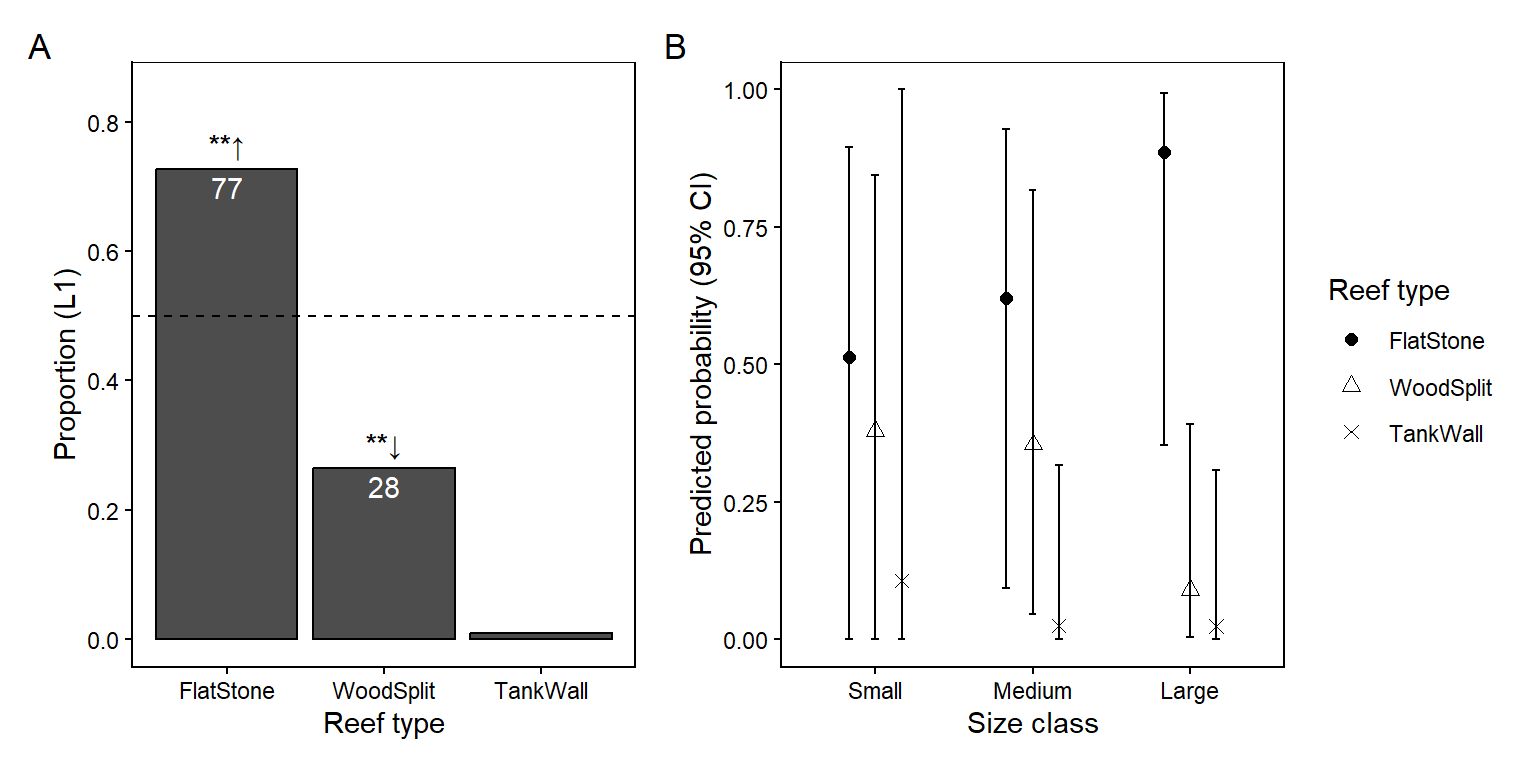

In [ ]:
#| label: fig-exp3
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp3_combined <- df_exp3_woodstone_long %>%
  filter(stage == "L1", !is.na(reef_type), reef_type != "NA") %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef3() %>%
  mutate(panel = "Combined")

ann_wilcox3 <- data.frame(
  reef_type = c("FlatStone", "WoodSplit"),
  label     = c(sig_label(p_wilcox3_adjusted["p_wilcox3_flat"]),
                sig_label(p_wilcox3_adjusted["p_wilcox3_split"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS3)) %>%
  left_join(exp3_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.04,
         label = case_when(
           reef_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"),
           reef_type %in% c("WoodSplit") & label != "ns" ~ paste0(label, "↓"),
           TRUE ~ label))

Exp3_combined_p <- exp3_combined %>%
  relevel_reef3() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox3, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.85)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce3_p <- pp_summary3 %>%
  filter(reef_type != "NA") %>%
  relevel_reef3() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(size_class, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 2, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  scale_x_discrete(labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Size class", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

Exp3_p <- Exp3_combined_p | ce3_p

ggsave(Exp3_p, file = file.path(out_dir, "fig-exp3.png"), width = 8, height = 4, dpi = 300)
Exp3_p

## Exp 3 II

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

(`geom_col()`).

(`geom_text()`).

(`geom_col()`).

(`geom_text()`).

...

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

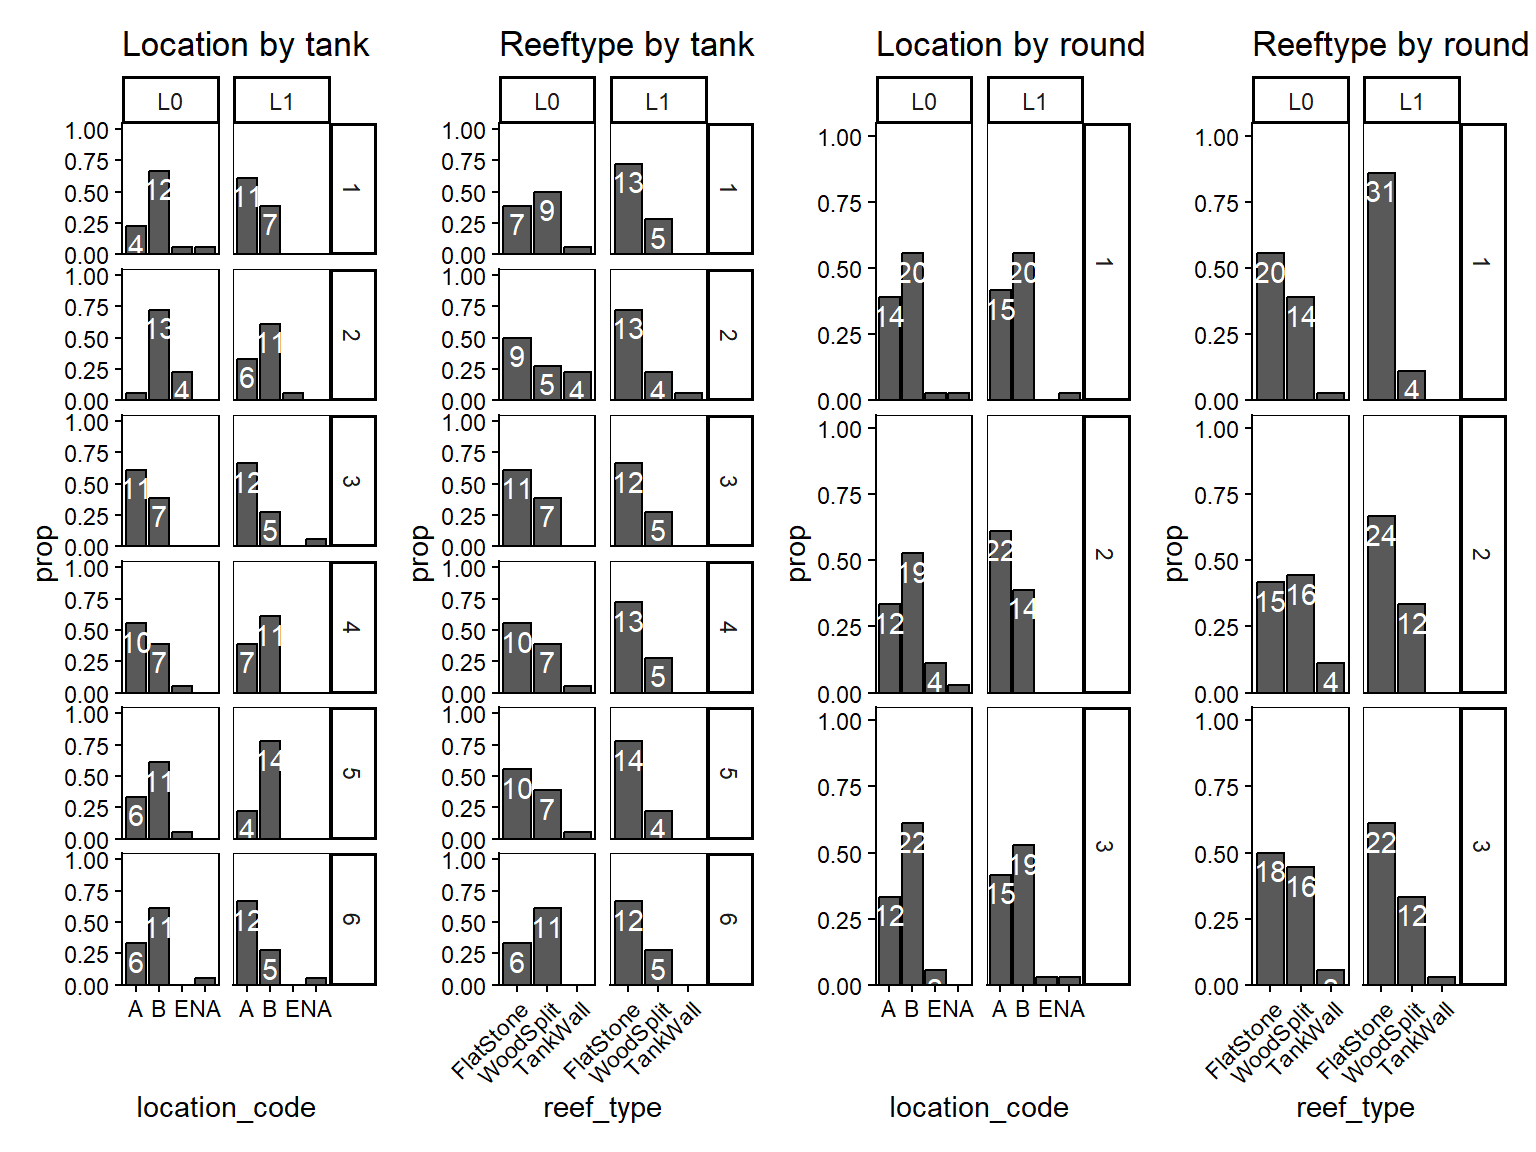

In [ ]:
#| label: fig-exp3-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

# bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS3, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }
  # data
  exp3_loc    <- mk_props(df_exp3_woodstone_long, location_code, tank)
  exp3_round  <- mk_props(df_exp3_woodstone_long, location_code, round)
  exp3_loc3   <- mk_props(df_exp3_woodstone_long, reef_type,     tank)
  exp3_round3 <- mk_props(df_exp3_woodstone_long, reef_type,     round)
  # plots
  p_exp3_loc    <- mk_bar(exp3_loc,   location_code, tank,  "Location by tank")
  p_exp3_round  <- mk_bar(exp3_round, location_code, round, "Location by round")
  p_exp3_loc3   <- mk_bar(exp3_loc3,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp3_round3 <- mk_bar(exp3_round3,reef_type,     round, "Reeftype by round", reef = TRUE)

loc_round_plots_exp3 <<- p_exp3_loc + p_exp3_loc3 + p_exp3_round + p_exp3_round3 +
    patchwork::plot_layout(ncol = 4)
}))

loc_round_plots_exp3

# Exp 4 Bricks

## Exp 4 Statistic

In [ ]:
#| label: stats-exp4
#| tbl-cap: "."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does sex affect reef preference? (brms categorical)

df4 <- df_exp4_brick_long %>%
  mutate(
    reef_type      = factor(reef_type),
    stage          = factor(stage, levels = c("L1")),
    sex            = factor(sex),
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(reef_type))

# RQ1 — Overall reef preference at group level
df4_grp <- df4 %>%
  count(group_id, round, reef_type) %>%
  filter(reef_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each reef type differs from uniform (.5)
wilcox_bart  <- wilcox.test(df4_grp$prop[df4_grp$reef_type == "BrickArtificial"],  mu = .5, exact = FALSE)
wilcox_bwood  <- wilcox.test(df4_grp$prop[df4_grp$reef_type == "BrickWood"],  mu = .5, exact = FALSE)


p_wilcox4_adjusted <- p.adjust(c(p_wilcox4_bart = wilcox_bart$p.value, p_wilcox4_bwood = wilcox_bwood$p.value), method = "bonferroni")

p_wilcox4_adjusted

 p_wilcox4_bart p_wilcox4_bwood 
      0.2731588       0.2731588 

[1] 0.1365794

  sum(Value)
1          0

 Family: categorical 
  Links: muBrickWood = logit; muTankWall = logit 
Formula: reef_type ~ sex + (1 | group_id/koura_id) + (1 | round) 
   Data: df4 %>% filter(stage == "L1") (Number of observations: 160) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 4) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muBrickWood_Intercept)     0.40      0.46     0.01     1.62 1.00     3444
sd(muTankWall_Intercept)      2.85      2.08     0.32     8.25 1.00     3024
                          Tail_ESS
sd(muBrickWood_Intercept)     4368
sd(muTankWall_Intercept)      2235

~group_id:koura_id (Number of levels: 40) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muBrickWood_Intercept)     0.47      0.30     0.03     1.14 1.00     2344
sd(muTankWall_Intercept)      1.99      0.94     0.41     4.12 1.00     2304
            

$group_id
$group_id$sd
                       Estimate Est.Error       Q2.5    Q97.5
muBrickWood_Intercept 0.4018498 0.4625928 0.01161197 1.617930
muTankWall_Intercept  2.8458576 2.0835434 0.31758074 8.253655


$`group_id:koura_id`
$`group_id:koura_id`$sd
                       Estimate Est.Error       Q2.5    Q97.5
muBrickWood_Intercept 0.4693453 0.3048817 0.02708613 1.136641
muTankWall_Intercept  1.9920035 0.9407559 0.40714010 4.115587


$round
$round$sd
                       Estimate Est.Error        Q2.5    Q97.5
muBrickWood_Intercept 0.3292526  0.382572 0.009059581 1.324963
muTankWall_Intercept  1.5403343  1.063708 0.163525128 4.276531

[1] 0.638375

## Exp 4 Table

In [ ]:
#| label: tbl-exp4
#| tbl-cap: "Experiment 4 Bayesian model fixed effects"

fixef(m_exp4_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)

  Parameter                  Mean     SD     2.5%   97.5%
  ----------------------- ------- ------ -------- -------
  muBrickWood_Intercept      0.20   0.51    -0.83    1.23
  muTankWall_Intercept      -1.44   2.59    -5.87    4.47
  muBrickWood_sexM          -0.18   0.53    -1.27    0.87
  muTankWall_sexM           -2.42   3.49   -11.02    2.23


## Exp 4 Figure

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

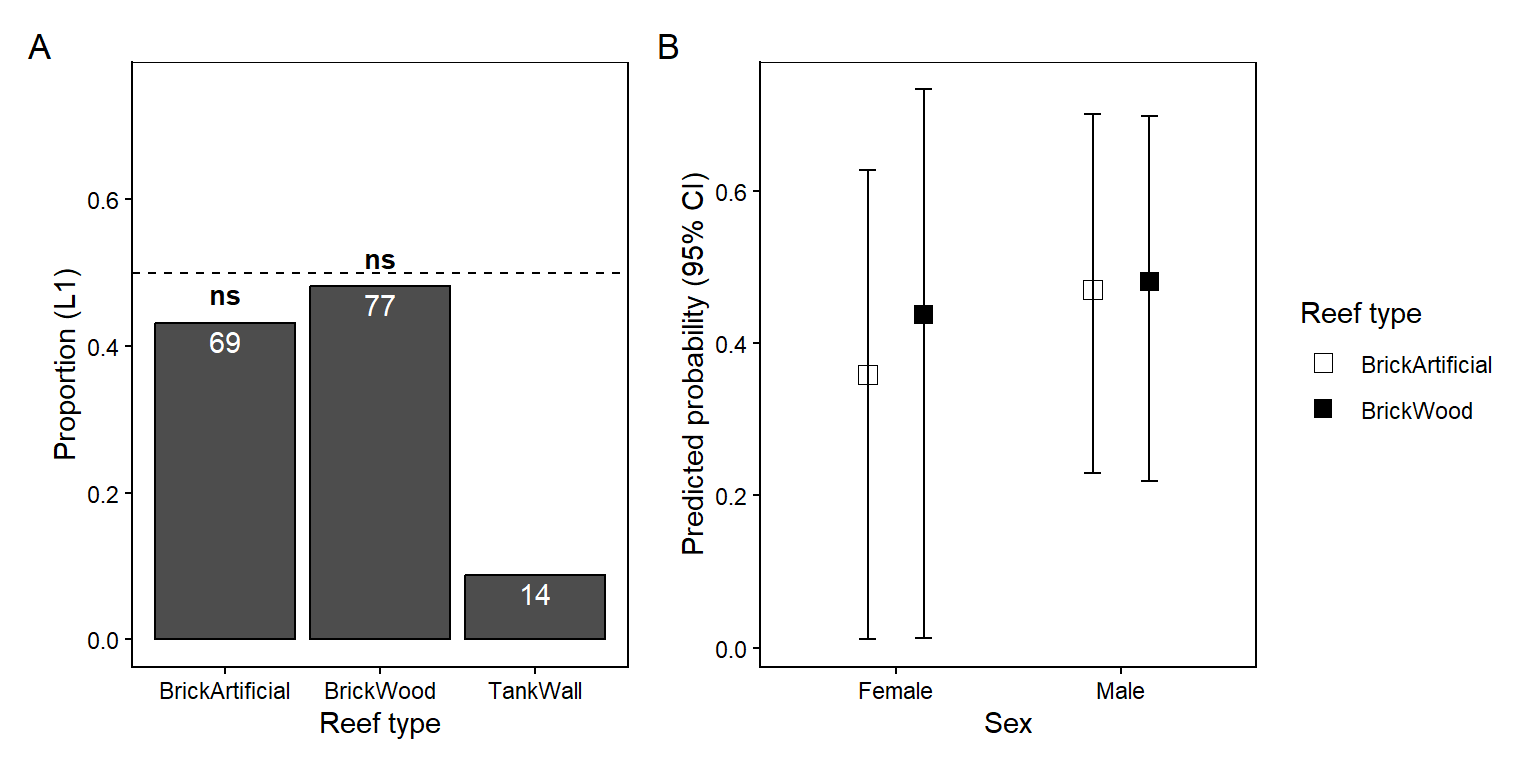

In [ ]:
#| label: fig-exp4
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp4_combined <- df_exp4_brick_long %>%
  filter(stage == "L1", !is.na(reef_type)) %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef4()

ann_wilcox4 <- data.frame(reef_type = c("BrickArtificial", "BrickWood"),label = c(sig_label(p_wilcox4_adjusted["p_wilcox4_bart"]), sig_label(p_wilcox4_adjusted["p_wilcox4_bwood"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS4)) %>%
  left_join(exp4_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.04, label = case_when( reef_type %in% c("BrickArtificial", "BrickWood") & label != "ns" ~ paste0(label, "↑"), TRUE ~ label))

Exp4_combined_p <- exp4_combined %>%
  relevel_reef4() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox4, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.75)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce4_p <- pp_summary4 %>%
  filter(reef_type != "TankWall") %>%
  relevel_reef4() %>%
  mutate(sex = factor(sex, levels = c("F", "M"), labels = c("Female", "Male"))) %>%
  ggplot(aes(sex, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  labs(x = "Sex", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

Exp4_p <- Exp4_combined_p | ce4_p

ggsave(Exp4_p, file = file.path(out_dir, "fig-exp4.png"), width = 8, height = 4, dpi = 300)

Exp4_p

## Exp 4 II

# A tibble: 20 × 5
   group_id size_class sex   reef_type           n
      <dbl> <chr>      <chr> <fct>           <int>
 1        7 L          F     BrickArtificial     2
 2        7 L          F     BrickWood           2
 3        7 M          F     BrickArtificial    15
 4        7 M          F     BrickWood           9
 5        7 M          F     TankWall            4
 6        7 S          F     BrickWood           8
 7        8 M          F     BrickArtificial    11
 8        8 M          F     BrickWood          15
 9        8 M          F     TankWall            2
10        8 M          M     BrickArtificial     2
11        8 M          M     BrickWood           2
12        8 S          F     BrickArtificial     2
13        8 S          F     BrickWood           2
14        8 S          M     BrickArtificial     2
15        8 S          M     BrickWood           2
16        9 M          M     BrickArtificial    15
17        9 M          M     BrickWood          17
18        9 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

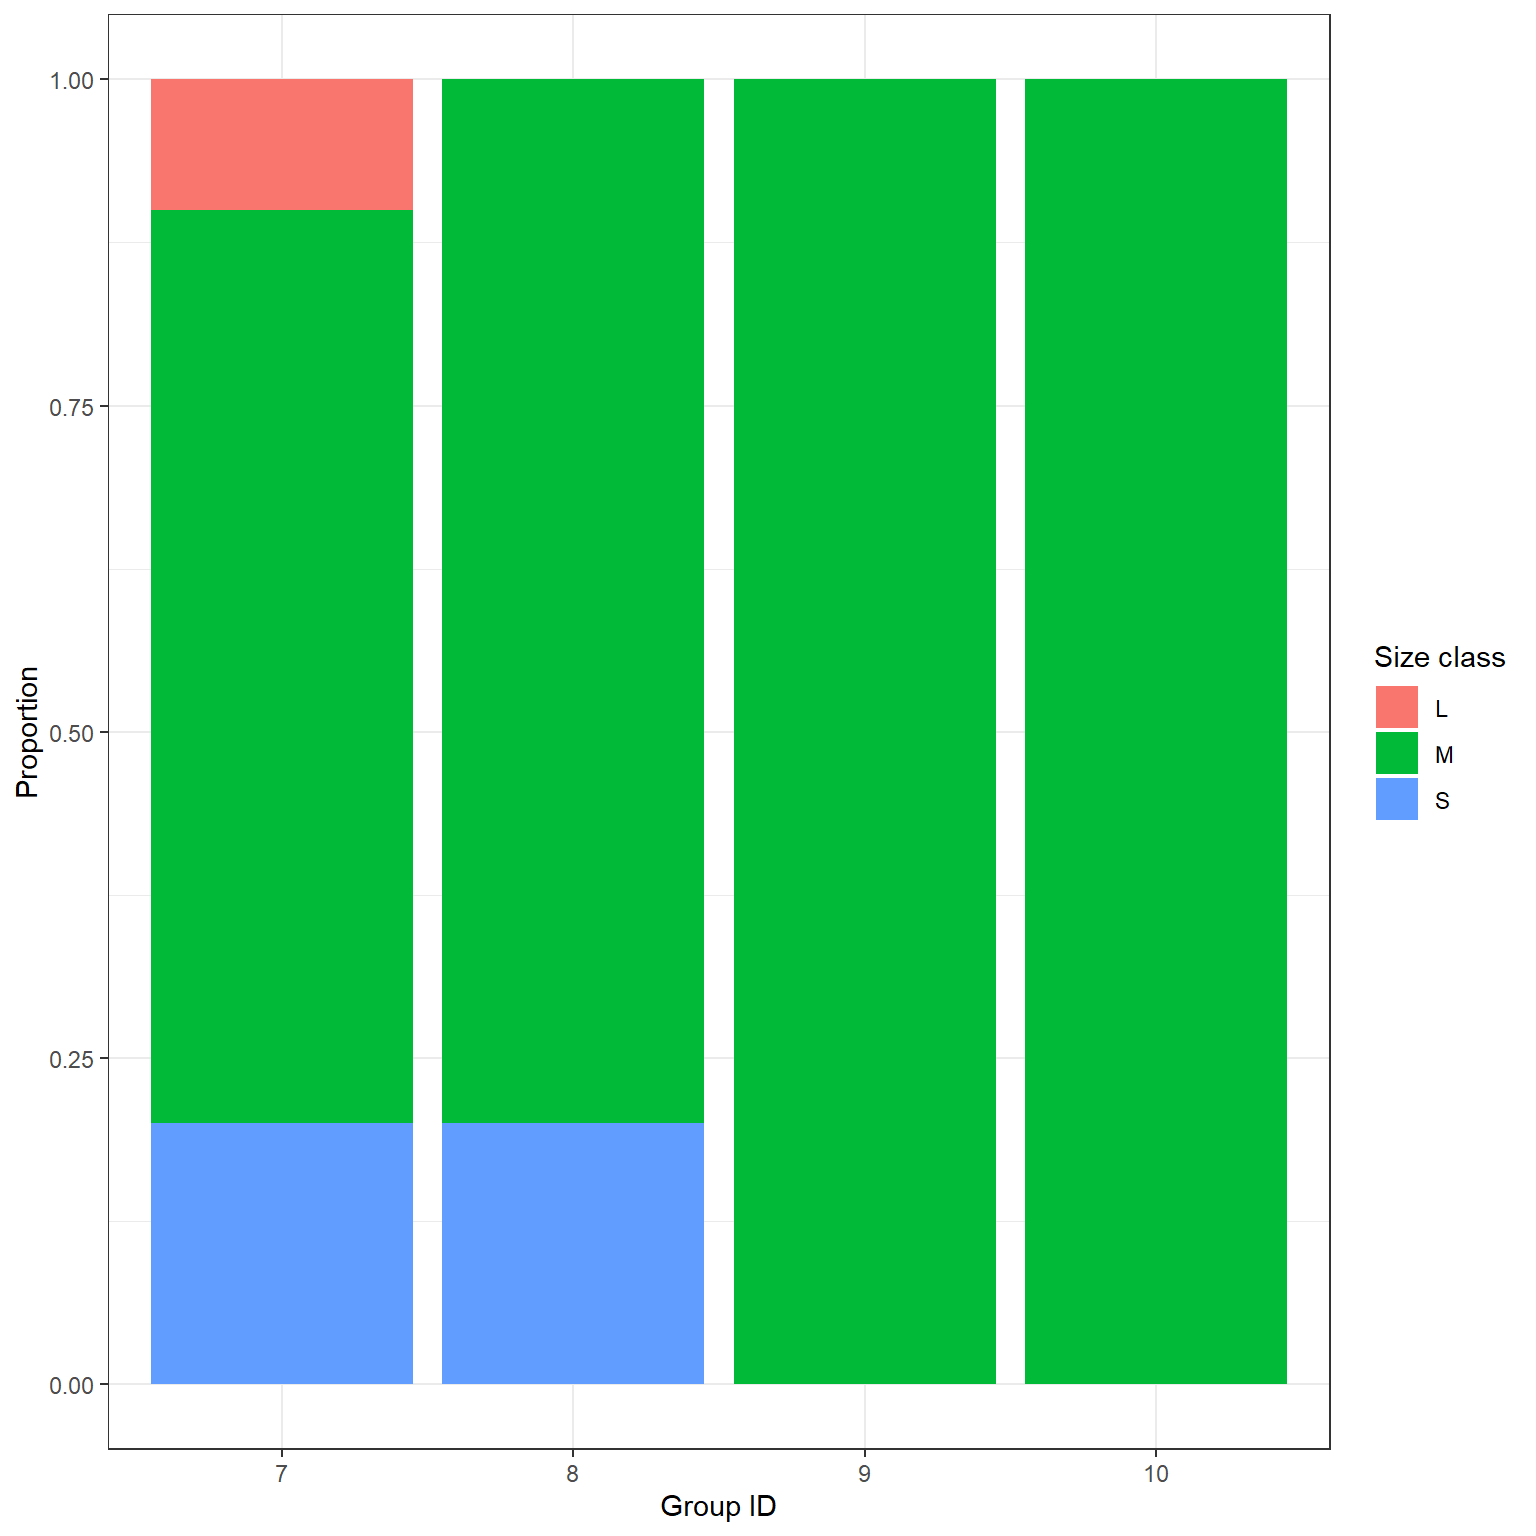

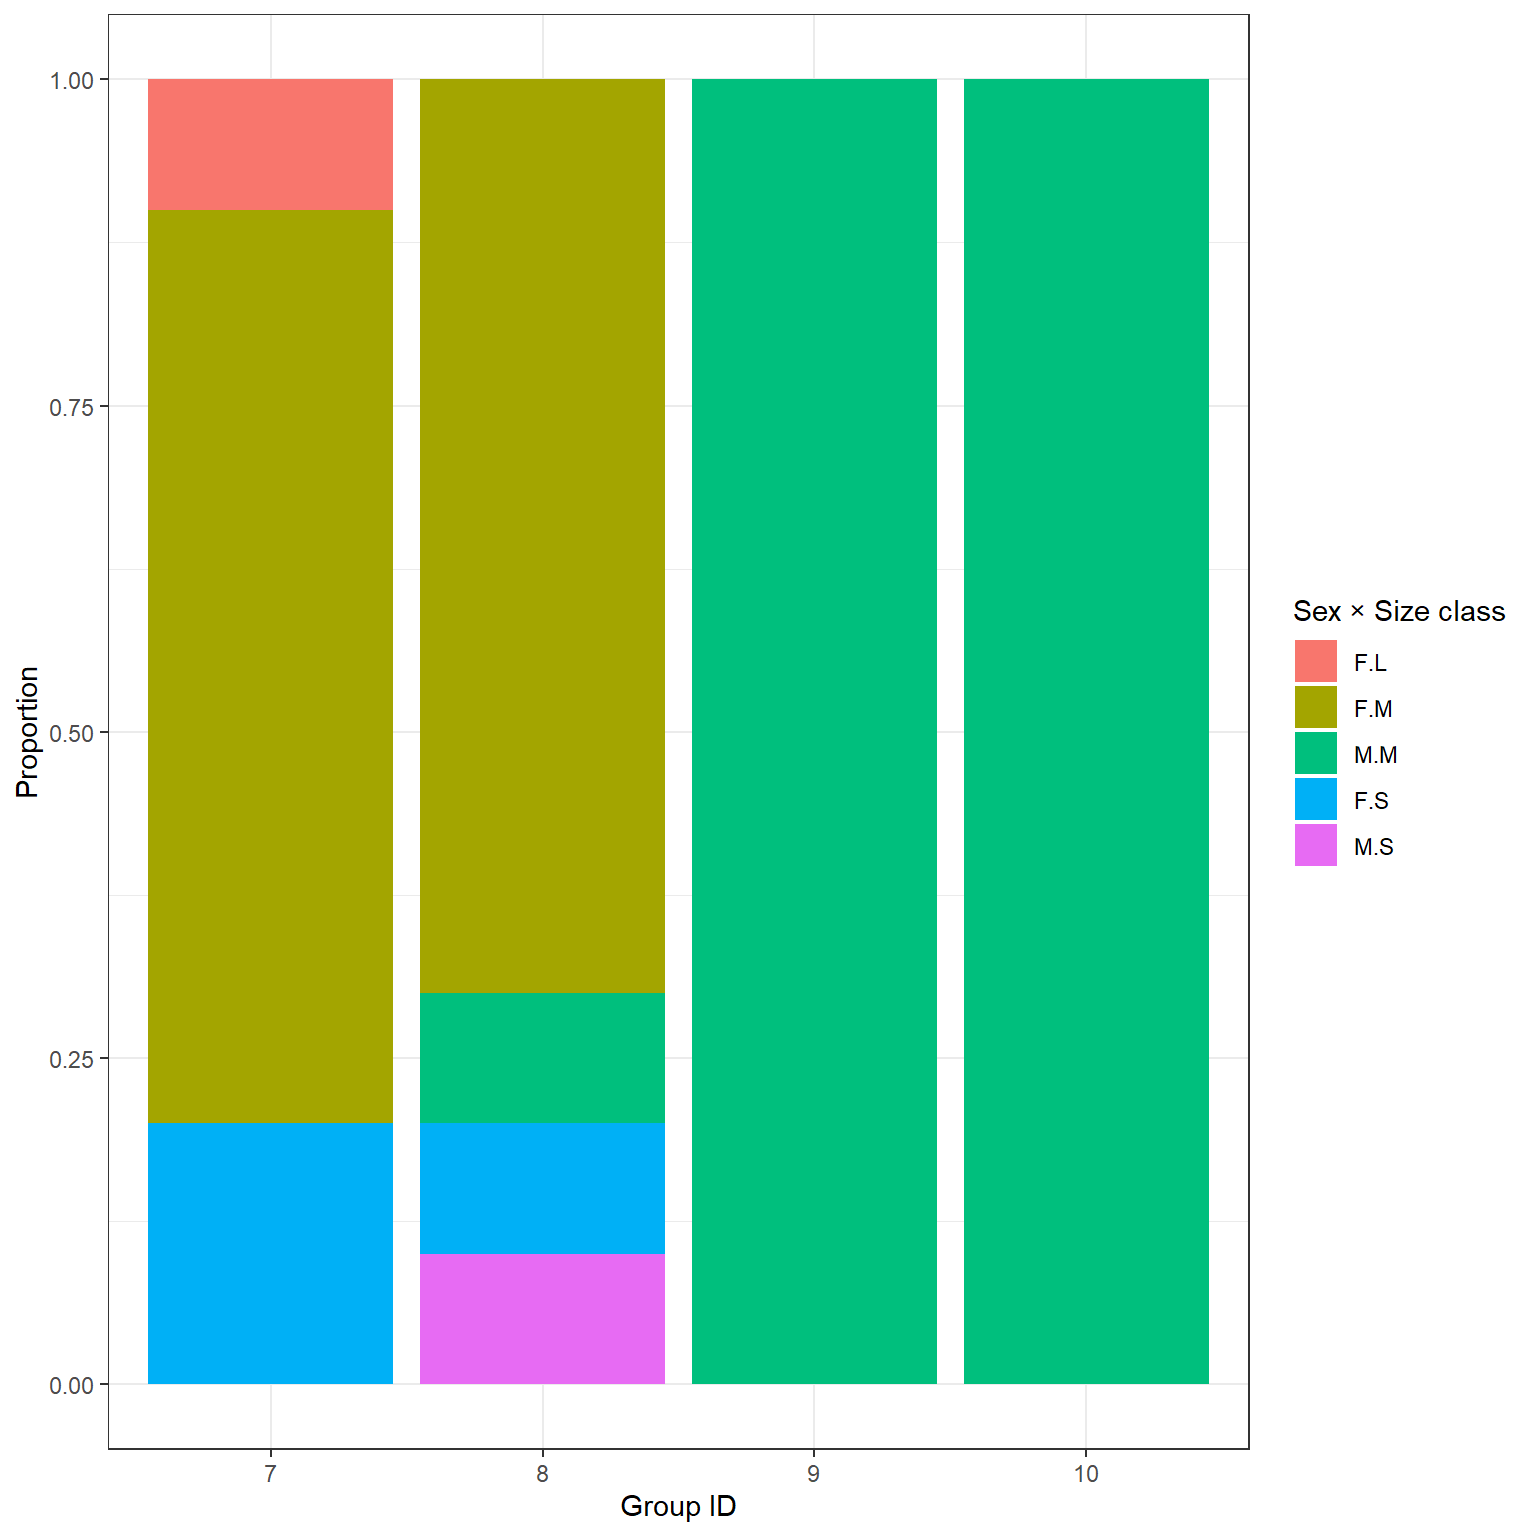

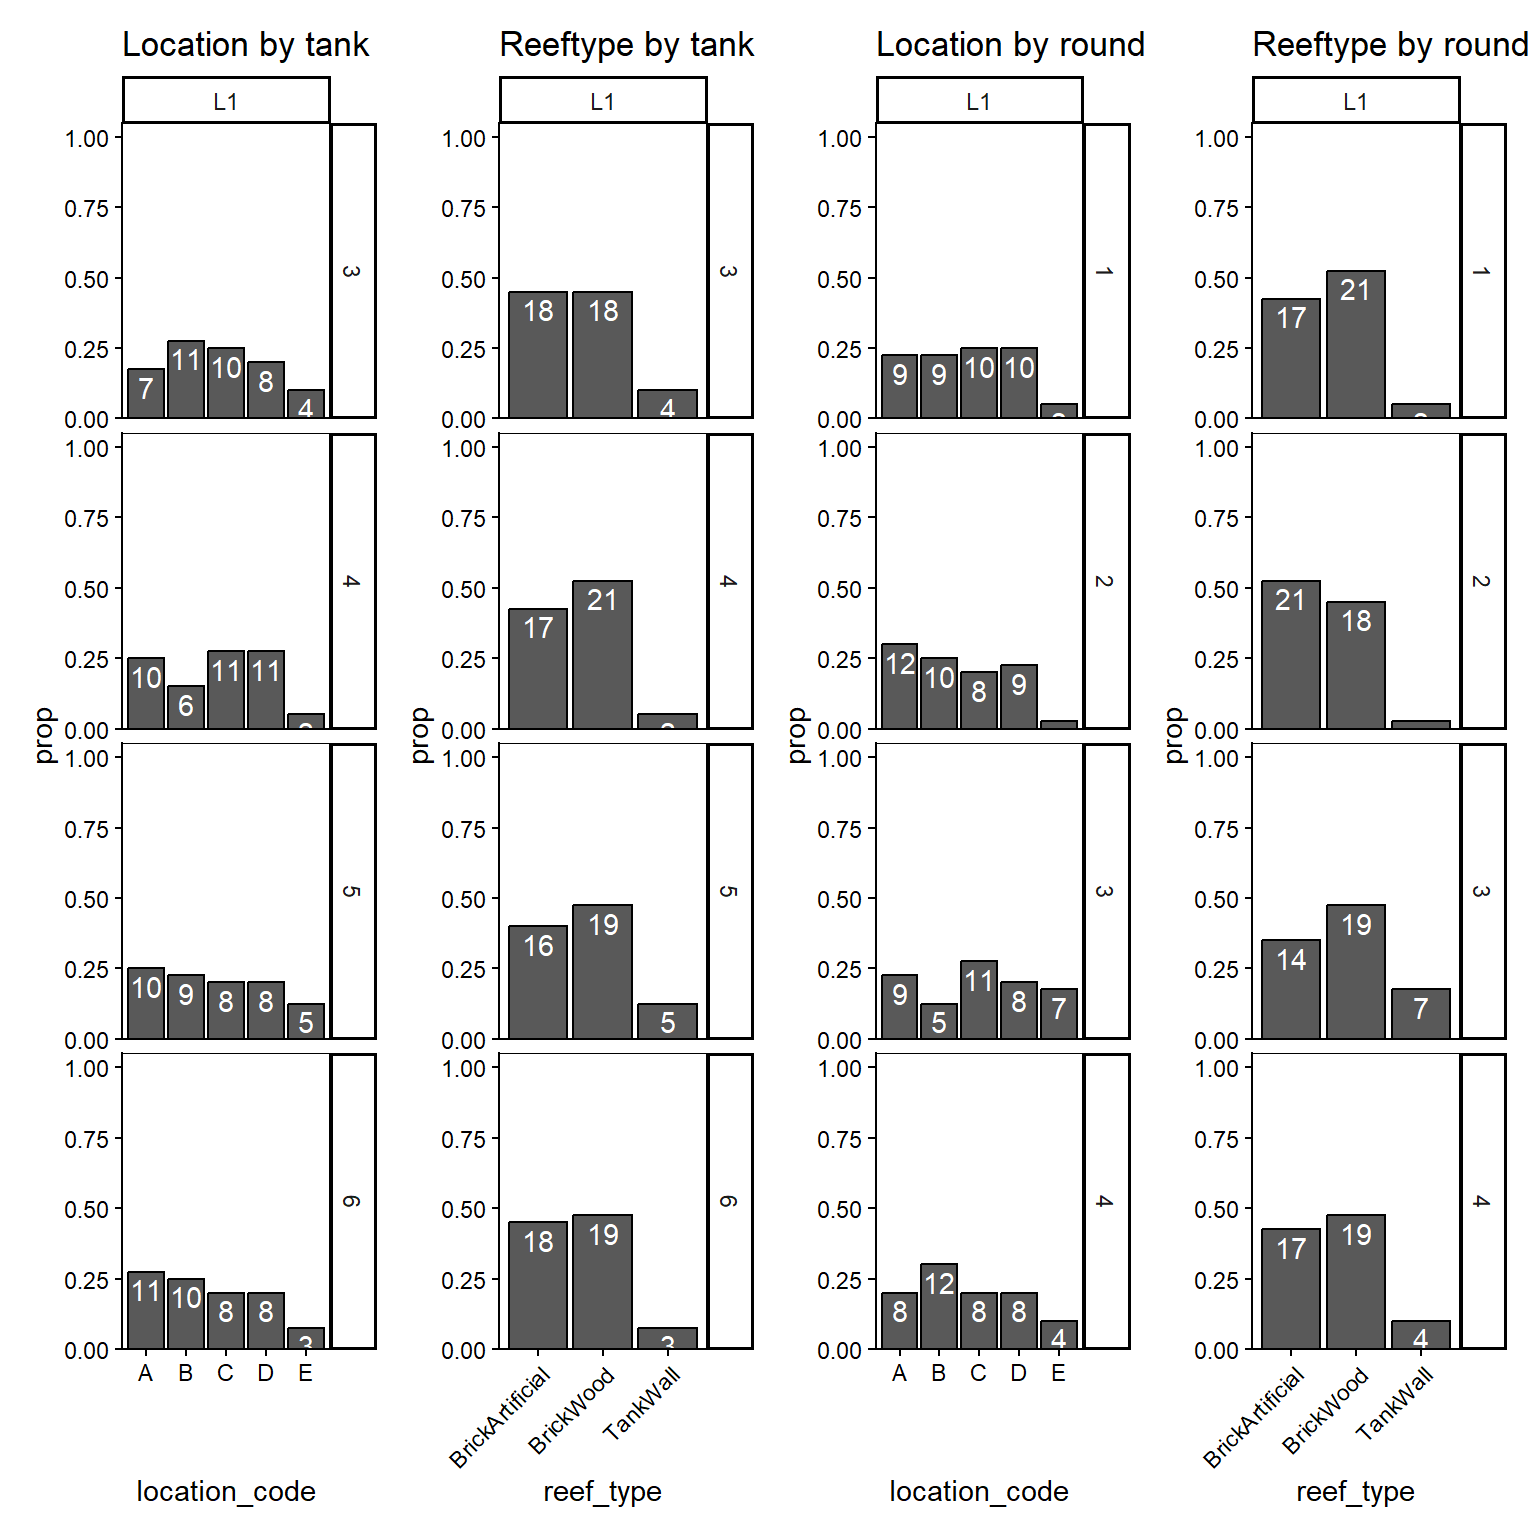

In [ ]:
#| label: fig-exp4-II
#| fig-width: 8
#| fig-height: 8
#| fig-cap: "."

df_exp4_brick_long %>%
  group_by(group_id, size_class, sex, reef_type) %>%
  summarise(n = n(), .groups = "drop") %>%
  arrange(group_id, size_class)

# Combine figure for presentation

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

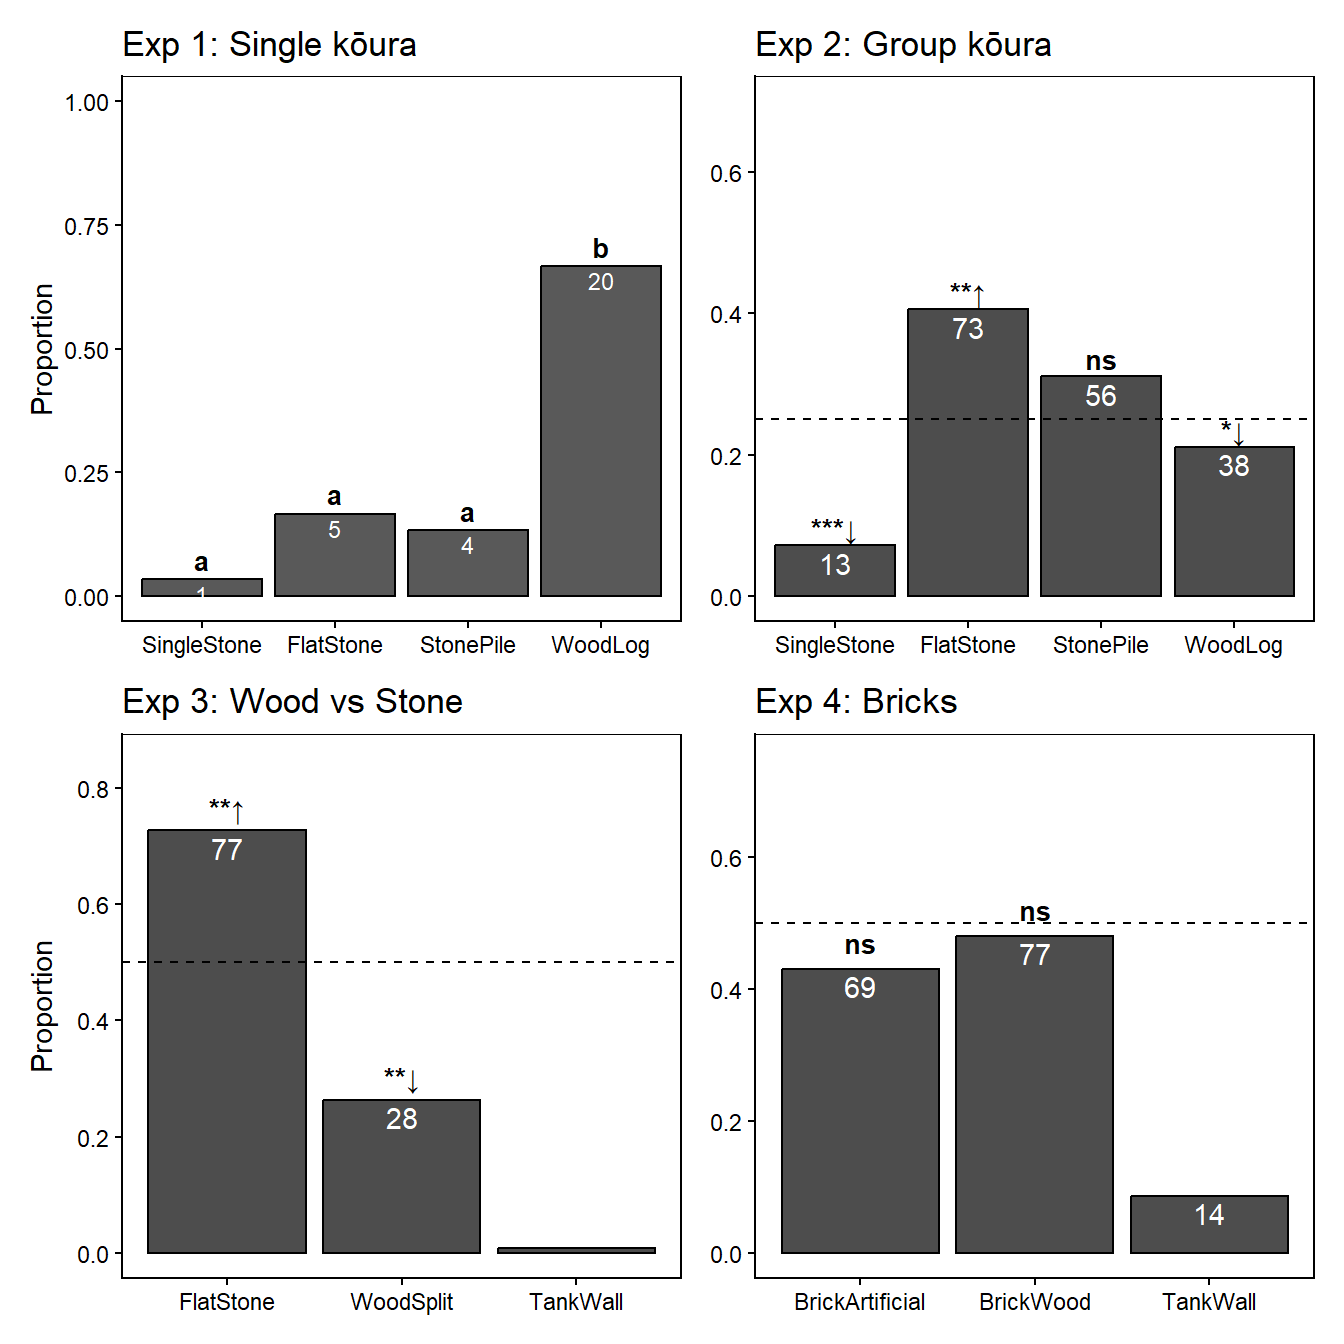

In [ ]:
#| label: fig-all-presentation
#| fig-width: 7
#| fig-height: 7
#| fig-cap: "."

p1 <- exp1_reef_all %>%
  relevel_reef() %>%
  filter(panel == "Combined", stage == "L1") %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white", size = 3) +
  geom_text(data = exp1_reef_letters %>% filter(panel == "Combined"),
    aes(y = prop + 0.04, label = cld_letter), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = NULL, y = "Proportion", title = "Exp 1: Single kōura")

p2 <- Exp2_combined_p + labs(x = NULL, y = NULL, title = "Exp 2: Group kōura", tag = NULL)
p3 <- Exp3_combined_p + labs(x = NULL, y = "Proportion", title = "Exp 3: Wood vs Stone", tag = NULL)
p4 <- Exp4_combined_p + labs(x = NULL, y = NULL, title = "Exp 4: Bricks", tag = NULL)

fig_all_presentation <- p1 + p2 + p3 + p4 + plot_layout(nrow = 2)

ggsave(fig_all_presentation, file = file.path(out_dir, "fig-all-presentation.png"), width = 6.5, height = 6.5, dpi = 300)
fig_all_presentation

# Waterquality

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

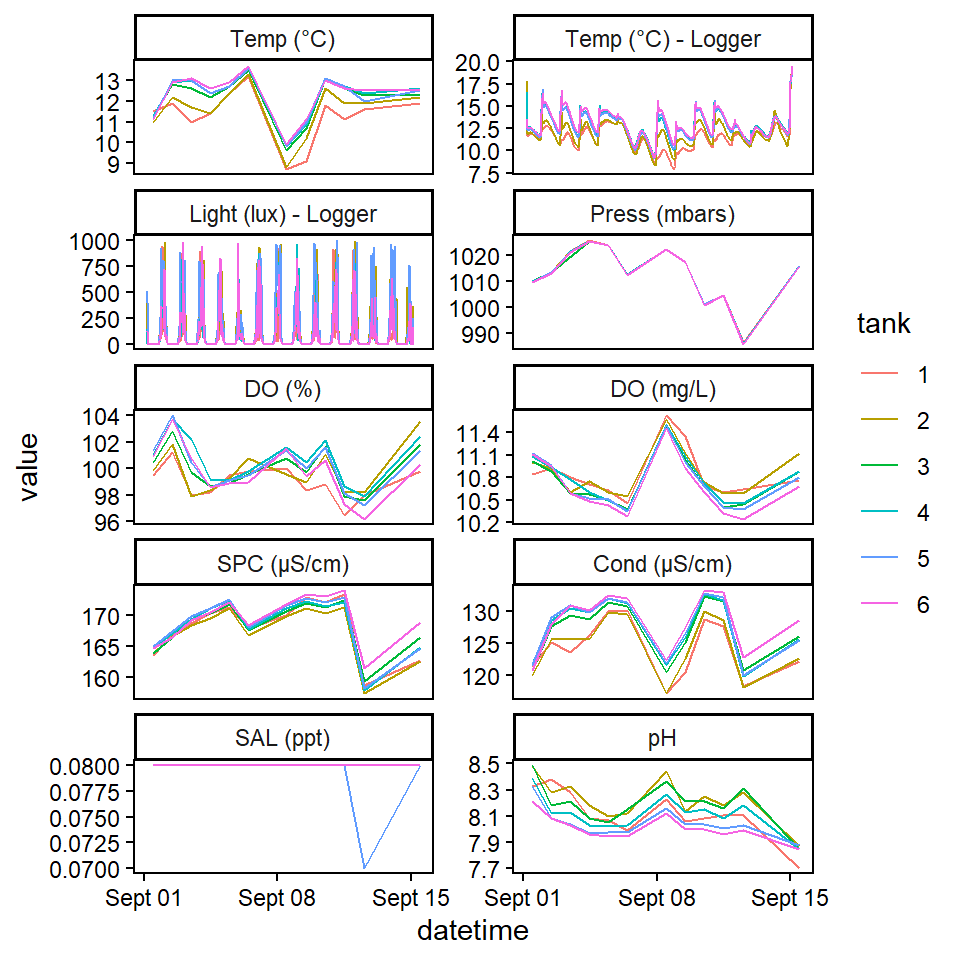

In [ ]:
#| label: fig-wq
#| fig-width: 5
#| fig-height: 5
#| fig-cap: "."

wq_clean <- df_wq %>%
  mutate(value = suppressWarnings(as.numeric(value)),tank  = factor(tank),param_label = ifelse(is.na(unit) | unit %in% c("", "NA"), parameter_abb, paste(parameter_abb, unit))) %>%
  filter(!is.na(tank_use), !is.na(value),data_time >= as.POSIXct("2025-09-01"),tank_use == "Experiment")

wq_probe <- wq_clean %>%
  transmute(datetime = data_time,tank,param_label,value)

# --- Logger data (df_loggers) -> give unique param_label names ---
wq_logger <- df_loggers %>%
  rename(datetime = data_time) %>%
  mutate(tank     = factor(tank),
    datetime = lubridate::ymd_hms(datetime, tz = "Pacific/Auckland")) %>%
  pivot_longer(c(temperature, light), names_to = "param", values_to = "value") %>%
  mutate(
    param_label = case_when(
      param == "temperature" ~ "Temp (°C) - Logger",
      param == "light"       ~ "Light (lux) - Logger",
      TRUE                   ~ param),
    date  = as.Date(datetime),
    time  = format(datetime, "%H:%M:%S"),
    year  = year(datetime),
    month = month(datetime, label = TRUE),
    day   = day(datetime)) %>%
  filter(
    datetime >= as.POSIXct("2025-09-01", tz = "Pacific/Auckland"),
    (param_label != "Light (lux) - Logger" | value <= 1000),
    (param_label != "Temp (°C) - Logger"   | value <= 20) ) %>%
  transmute(datetime, date, time, year, month, day, tank, param_label, value)

# --- Combine into ONE df, keep labels distinct ---
PARAM_LEVELS <- c("Temp (°C)", "Temp (°C) - Logger","Light (lux) - Logger",
                  "Press (mbars)","DO (%)","DO (mg/L)","SPC (µS/cm)","Cond (µS/cm)","SAL (ppt)","pH")

wq_all <- bind_rows(wq_probe, wq_logger) %>%
  mutate(param_label = factor(param_label, levels = PARAM_LEVELS),tank = factor(tank)) %>%
  tidyr::drop_na(value)

# --- Plot from the single df ---
wq_all_plot <- ggplot(wq_all, aes(datetime, value, color = tank, group = tank)) +
  geom_line() +
  facet_wrap(~ param_label, scales = "free_y", ncol = 2)

wq_all_plot

# Length-Weight of koura

# A tibble: 1 × 8
  n_size n_weight size_mm1_mean size_mm1_sd size_mm1_range weight_g1_mean
   <int>    <int>         <dbl>       <dbl> <chr>                   <dbl>
1     30       30          26.5        2.13 22.61–29.97              12.2
# ℹ 2 more variables: weight_g1_sd <dbl>, weight_g1_range <chr>

# A tibble: 1 × 8
  n_size n_weight size_mm1_mean size_mm1_sd size_mm1_range weight_g1_mean
   <int>    <int>         <dbl>       <dbl> <chr>                   <dbl>
1    180      180          27.3        7.57 15.77–43.34              15.8
# ℹ 2 more variables: weight_g1_sd <dbl>, weight_g1_range <chr>

# A tibble: 1 × 8
  n_size n_weight size_mm1_mean size_mm1_sd size_mm1_range weight_g1_mean
   <int>    <int>         <dbl>       <dbl> <chr>                   <dbl>
1    108      108          27.4        7.56 15.77–43.34              15.9
# ℹ 2 more variables: weight_g1_sd <dbl>, weight_g1_range <chr>

# A tibble: 1 × 8
  n_size n_weight size_mm1_mean size_mm1_sd size_mm1_range weight_g1_mean
   <int>    <int>         <dbl>       <dbl> <chr>                   <dbl>
1    160      160          26.1        2.58 20.21–30.81              11.9
# ℹ 2 more variables: weight_g1_sd <dbl>, weight_g1_range <chr>

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

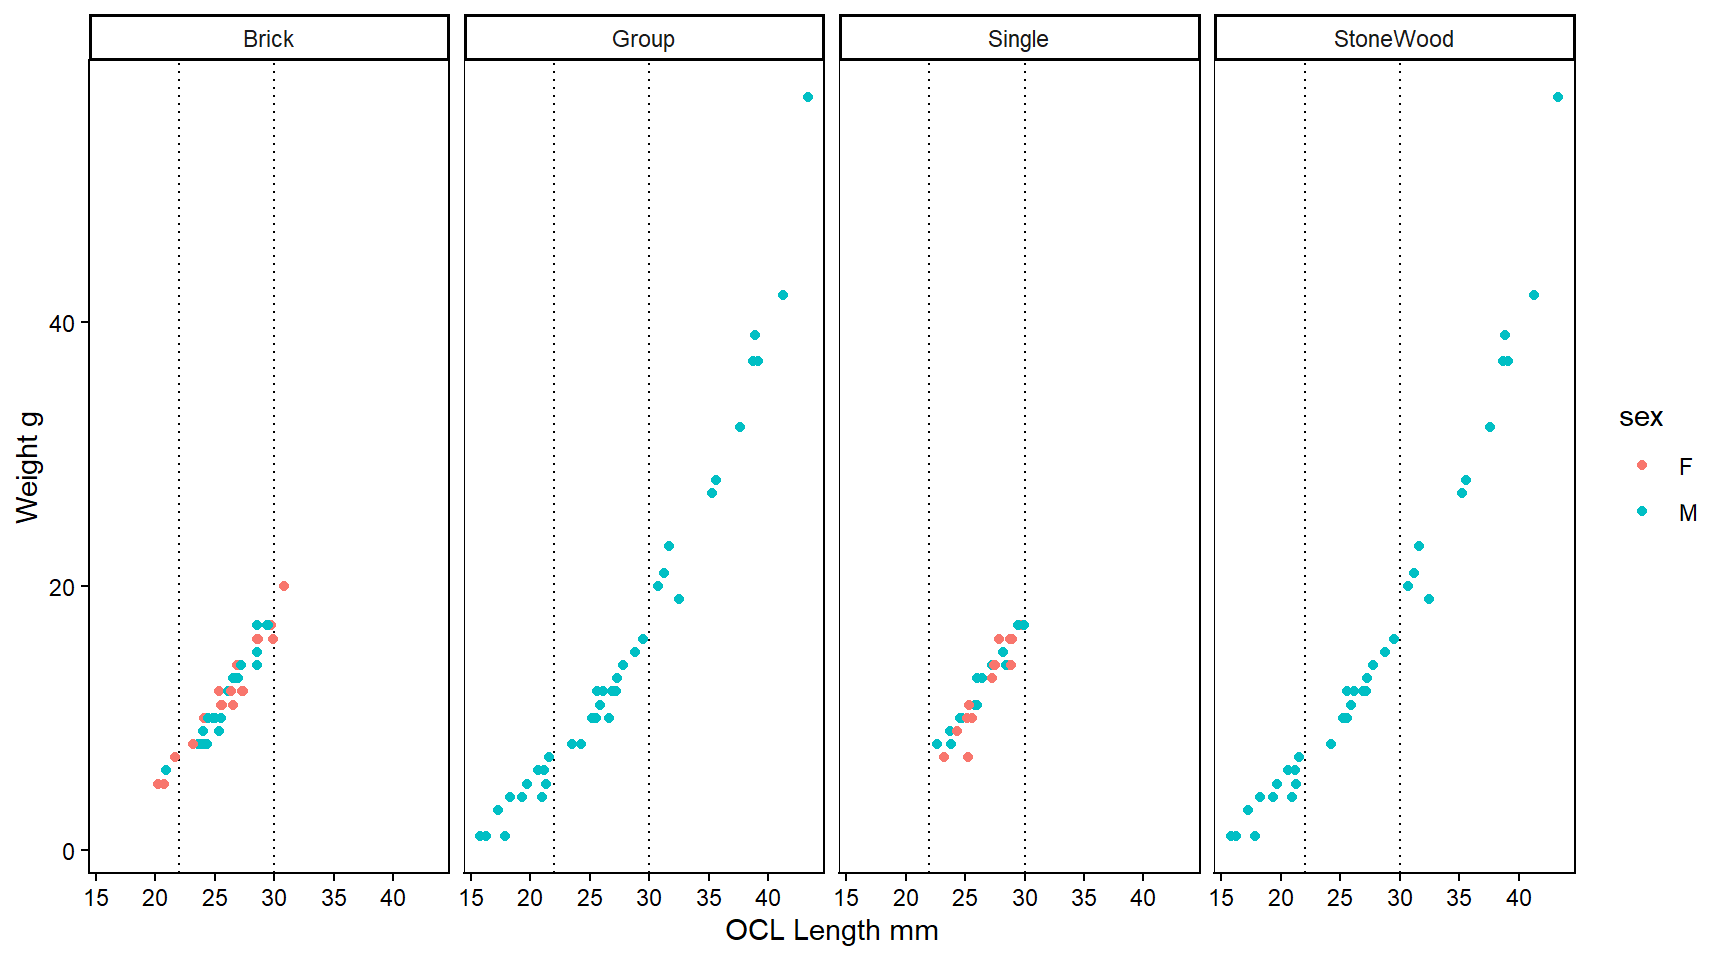

In [ ]:
#| label: fig-length-weight
#| fig-width: 9
#| fig-height: 5
#| fig-cap: "."

summarise_size_weight <- function(df) {
  df %>%
    summarise(
      n_size          = sum(!is.na(size_mm1)),
      n_weight        = sum(!is.na(weight_g1)),
      size_mm1_mean   = mean(size_mm1, na.rm = TRUE),
      size_mm1_sd     = sd(size_mm1, na.rm = TRUE),
      size_mm1_range  = paste0(min(size_mm1, na.rm = TRUE), "–", max(size_mm1, na.rm = TRUE)),
      weight_g1_mean  = mean(weight_g1, na.rm = TRUE),
      weight_g1_sd    = sd(weight_g1, na.rm = TRUE),
      weight_g1_range = paste0(min(weight_g1, na.rm = TRUE), "–", max(weight_g1, na.rm = TRUE))
    )
}

summarise_size_weight(df_exp1_single_raw)

# Session info

In [ ]:
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()

R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] writexl_1.5.4       readxl_1.4.5        forcats_1.0.1      
 [4] dplyr_1.2.0         purrr_1.2.1         readr_2.2.0        
 [7] tidyr_1.3.2         tibble_3.3.1        ggplot2_4.0.2      
[10] tidyverse_2.0.0     stringr_1.6.0       lubridate_1.9.5    
[13] janitor_2.2.1       patchwork_1.3.2     multcompView_0.1-11
[16] lme4_1.1-38         Matrix_1.7-4        nnet_7.3-20        
[19] brms_2.23.0         Rcpp_1.1.1          XNomial_1.0.4.1    


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false
packages <- c("emmeans","DescTools", "coin","XNomial","brms","nnet","lme4","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

# Set paths
exc_file_dir    <- "data/raw/Mesocosm_experiment.xlsx"
raw_data_dir    <- "data/raw"
der_data_dir    <- "data/derived"
out_dir         <- "outputs"

read_sheet <- function(sheet) {readxl::read_excel(exc_file_dir, sheet = sheet)}
write_out <- function(df, name) {write.csv(df, file.path(der_data_dir, name), row.names = FALSE)}

# Read data
df_koura               <- read_sheet("Koura")
df_setup               <- read_sheet("Tank_setup")
df_exp1_single_raw     <- read_sheet("Reef_single")
df_exp2_group_raw      <- read_sheet("Reef_group")
df_exp3_woodstone_raw  <- read_sheet("Stone_wood")
df_exp4_brick_raw      <- read_sheet("Bricks")
df_wq                  <- read_sheet("WQ")
df_loggers             <- read_sheet("Loggers")

# Save as csv to derived
write_out(df_koura,              "df_koura.csv")
write_out(df_setup,              "df_setup.csv")
write_out(df_exp1_single_raw,    "df_exp1_single_raw.csv")
write_out(df_exp2_group_raw,     "df_exp2_group_raw.csv")
write_out(df_exp3_woodstone_raw, "df_exp3_woodstone_raw.csv")
write_out(df_exp4_brick_raw,     "df_exp4_brick_raw.csv")
write_out(df_wq,                 "df_wq.csv")
write_out(df_loggers,            "df_loggers.csv")

# set preferred orders
REEF_LEVELS  <- c("SingleStone","FlatStone","StonePile","WoodLog","TankWall")
REEF_LEVELS3 <- c("FlatStone","WoodSplit","TankWall")
REEF_LEVELS4 <- c("BrickArtificial","BrickWood","TankWall")
LOC_LEVELS   <- c("A", "B", "C", "D", "E")
LOC_LEVELS3  <- c("A", "B", "E")

relevel_reef  <- function(df) df %>% mutate(reef_type = factor(as.character(reef_type),levels = REEF_LEVELS))
relevel_reef3 <- function(df) df %>% mutate(reef_type = factor(as.character(reef_type),levels = REEF_LEVELS3))
relevel_reef4 <- function(df) df %>% mutate(reef_type = factor(as.character(reef_type),levels = REEF_LEVELS4))

# Set plot theme
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.5))
theme_set(base_theme_bw)

# Build pairwise_gtest
pairwise_gtest <- function(counts) {
  nms   <- names(counts)
  pairs <- combn(nms, 2, simplify = FALSE)
  
  results <- lapply(pairs, function(p) {
    obs_pair <- counts[p]
    exp_pair <- rep(sum(obs_pair) / 2, 2)
    
    G     <- 2 * sum(obs_pair * log(obs_pair / exp_pair), na.rm = TRUE)
    p_val <- pchisq(G, df = 1, lower.tail = FALSE)
    
    data.frame(
      pair  = paste(p, collapse = " vs "),
      G     = round(G, 3),
      p_raw = round(p_val, 4)
    )
  })
  
  out       <- do.call(rbind, results)
  out$p_adj <- round(p.adjust(out$p_raw, method = "bonferroni"), 4)
  out
}

# Function to convert pairwise G-test results to CLD letters
gtest_to_cld <- function(pgtest_result) {
    pvals <- setNames(
    pgtest_result$p_adj,
    gsub(" vs ", "-", pgtest_result$pair))
  multcompView::multcompLetters(pvals)$Letters
}

# Format of p values in text
format_pval <- function(p) {
  if (p < 0.001) {
    return("<0.001")
  } else {
    return(format(round(p, 3), nsmall = 3))
  }
}

sig_label <- function(p) {
  case_when(
    p < 0.001 ~ "***",
    p < 0.01  ~ "**",
    p < 0.05  ~ "*",
    p < 0.1   ~ ".",
    TRUE      ~ "ns"
  )
}

get_brms <- function(model, param, col = "Estimate") {
  tbl <- fixef(model) %>% as.data.frame() %>% rownames_to_column("parameter")
  round(tbl[[col]][tbl$parameter == param], 2)
}

format_brms <- function(model, param, post_prob = NULL) {
  b    <- get_brms(model, param)
  low  <- get_brms(model, param, "Q2.5")
  high <- get_brms(model, param, "Q97.5")
  base <- paste0("(\u03b2 = ", b, ", 95% CI: ", low, " to ", high)
  if (!is.null(post_prob)) paste0(base, "; posterior probability = ", round(post_prob, 2), ")")
  else paste0(base, ")")
}

shape_map <- c(SingleStone = 1, FlatStone = 16, StonePile = 18, WoodLog = 17, WoodSplit = 2, BrickArtificial = 0, BrickWood = 15, TankWall = 4)

```


# Build DF's into long format
quarto-executable-code-5450563D

```r
#| label: build_dfs

df_exp1_single_long <- df_exp1_single_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = matches("_(l0|l1)$"),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    reef_type     = factor(reef, levels = REEF_LEVELS)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, size_mm1, weight_g1, date, stage, t_leave_s, t_l0_s, location_code, reef_type,legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp1_single_long, "df_exp1_single_long.csv")

# EXP 2 – Group reefs (long)
df_exp2_group_long <- df_exp2_group_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1,
      reef_l0, reef_l1,legs_l0, claws_l0, antenna_l0,legs_l1, claws_l1, antenna_l1), names_to = c(".value", "stage"), names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage          = toupper(stage),
    location_code  = factor(toupper(location), levels = LOC_LEVELS),
    reef_type      = factor(reef, levels = REEF_LEVELS),
    size_mm_stage  = if_else(stage == "L0", size_mm1, size_mm2, NA_real_),
    weight_g_stage = if_else(stage == "L0", weight_g1, weight_g2, NA_real_)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date,stage, t_leave_s, t_l0_s, location_code, reef_type,legs, claws, antenna, size_mm_stage, weight_g_stage,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp2_group_long, "df_exp2_group_long.csv")


# EXP 3 – Stone / wood (long)
df_exp3_woodstone_long <- df_exp3_woodstone_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1, reef_l0, reef_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS3),
    reef_type     = factor(reef, levels = REEF_LEVELS3)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, reef_type, size_mm1, weight_g1, legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2, notes_exp, notes_koura)

write_out(df_exp3_woodstone_long, "df_exp3_woodstone_long.csv")


# EXP 4 – Bricks (long)
df_exp4_brick_long <- df_exp4_brick_raw %>%
  mutate(location_l1 = l1) %>%
  pivot_longer(cols = c(location_l1, reef_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    reef_type     = factor(reef, levels = REEF_LEVELS4)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, reef_type,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp4_brick_long, "df_exp4_brick_long.csv")
```

# Exp 1 Single koura
## Exp 1 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp1
#| tbl-cap: "Exp 1 statistical results"

# RQ 1: Is there a statistical difference between reef type in L1?
# RQ 2: Is there a preference within each sex?
# RQ 3: Does reef type differ between sex?
# RQ 4: Did reef type use shift directionally between L0 and L1?

df1 <- df_exp1_single_long %>%
  mutate(
    reef_type     = factor(reef_type),
    stage         = factor(stage, levels = c("L0", "L1")),
    sex           = factor(sex),
    size_class    = factor(size_class),
    location_code = factor(location_code),
    tank          = factor(tank),
    round         = factor(round),
    koura_id      = factor(koura_id),
    size_mm1      = as.numeric(size_mm1),
    weight_g1     = as.numeric(weight_g1)) %>%
  filter(!is.na(reef_type))

df1_L1 <- df1 %>% filter(stage == "L1" , reef_type != "TankWall") %>%
  mutate(reef_type = droplevels(reef_type))

pct_wood_overall <- round(mean(df1_L1$reef_type == "WoodLog") * 100)
pct_wood_male    <- round(mean(df1_L1$reef_type[df1_L1$sex == "M"] == "WoodLog") * 100)
pct_wood_female  <- round(mean(df1_L1$reef_type[df1_L1$sex == "F"] == "WoodLog") * 100)

# RQ1 — Reef type preference at L1
tab1_L1 <- table(df1_L1$reef_type)
tab1_L1_nz <- tab1_L1[tab1_L1 > 0]

xmulti1 <- XNomial::xmulti(obs  = as.numeric(tab1_L1_nz), expr = rep(sum(tab1_L1_nz) / length(tab1_L1_nz), length(tab1_L1_nz)))
p_xmulti1 <- xmulti1$pLLR

# Post-hoc pairwise G-tests
pgtest1 <- pairwise_gtest(tab1_L1_nz)
p_single_vs_flat1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs FlatStone"]
p_single_vs_pile1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs StonePile"]
p_single_vs_wood1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs WoodLog"]
p_flat_vs_pile1   <- pgtest1$p_adj[pgtest1$pair == "FlatStone vs StonePile"]
p_flat_vs_wood1   <- pgtest1$p_adj[pgtest1$pair == "FlatStone vs WoodLog"]
p_pile_vs_wood1   <- pgtest1$p_adj[pgtest1$pair == "StonePile vs WoodLog"]

# Generate CLD letters for each panel
cld_combined1 <- data.frame(
  stage      = "L1",
  panel      = "Combined",
  reef_type  = names(gtest_to_cld(pgtest1)),
  cld_letter = unname(gtest_to_cld(pgtest1)))

# RQ2 — Sex difference in reef preference at L1
tab1_sex     <- table(df1_L1$reef_type, df1_L1$sex)
fisher1      <- fisher.test(tab1_sex, simulate.p.value = TRUE, B = 9999)
p_fisher1    <- fisher1$p.value

# RQ3 — Preference within each sex
reef_levels <- names(tab1_L1_nz)

xmulti1_female <- XNomial::xmulti(
  obs  = as.numeric(table(df1_L1$reef_type[df1_L1$sex == "F"])),
  expr = rep(1/4, 4))
xmulti1_male <- XNomial::xmulti(
  obs  = as.numeric(table(df1_L1$reef_type[df1_L1$sex == "M"])),
  expr = rep(1/4, 4))

if (xmulti1_female$pLLR < 0.05) {
  pgtest1_female <- pairwise_gtest(table(df1_L1$reef_type[df1_L1$sex == "F"]))
  cld_female1    <- data.frame(stage = "L1", panel = "Female",
    reef_type  = names(gtest_to_cld(pgtest1_female)),
    cld_letter = unname(gtest_to_cld(pgtest1_female)))} else {
  cld_female1 <- data.frame(stage = "L1", panel = "Female",
    reef_type = reef_levels, cld_letter = "a")}

if (xmulti1_male$pLLR < 0.05) {
  pgtest1_male <- pairwise_gtest(table(df1_L1$reef_type[df1_L1$sex == "M"]))
  cld_male1    <- data.frame(stage = "L1", panel = "Male",
    reef_type  = names(gtest_to_cld(pgtest1_male)),
    cld_letter = unname(gtest_to_cld(pgtest1_male)))} else {
  cld_male1 <- data.frame(stage = "L1", panel = "Male",
    reef_type = reef_levels, cld_letter = "a")}

cld_all1 <- bind_rows(cld_combined1, cld_female1, cld_male1)

# RQ4 — Directional shift between L0 and L1
df1_wide     <- df1 %>%
  select(koura_id, stage, reef_type) %>%
  pivot_wider(names_from = stage, values_from = reef_type)

tab1_trans   <- table(L0 = df1_wide$L0, L1 = df1_wide$L1)
symtest1     <- coin::symmetry_test(tab1_trans, distribution = approximate(nresample = 9999))
p_symtest1   <- pvalue(symtest1)
```

## Exp 1 figure
quarto-executable-code-5450563D

```r
#| label: fig-exp1
#| fig-width: 4
#| fig-height: 6
#| fig-cap: "."

exp1_reef_combined <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, reef_type, name = "n") %>%
  group_by(stage) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef() %>%
  mutate(panel = "Combined")

exp1_reef_bysex <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, reef_type, sex, name = "n") %>%
  group_by(stage, sex) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef() %>%
  mutate(panel = dplyr::recode(sex, F = "Female", M = "Male")) %>%
  select(-sex)

lab_panel1 <- c(Combined = "Combined", Female = "Female", Male = "Male")

exp1_reef_all <- dplyr::bind_rows(exp1_reef_combined, exp1_reef_bysex)

exp1_reef_letters <- exp1_reef_all %>%
  relevel_reef() %>%
  filter(stage == "L1") %>%
  left_join(cld_all1, by = c("stage", "panel", "reef_type"))

Exp1_reef_p <- exp1_reef_all %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = exp1_reef_letters,aes(y = prop + 0.04, label = cld_letter), size  = 3.5, fontface = "bold") +
  facet_wrap(~ panel, ncol = 1, labeller = labeller(panel = lab_panel1)) +
  labs(x = "Reef type", y = "Proportion (L1)")

ggsave(Exp1_reef_p, file = file.path(out_dir, "fig-exp1.png"), width = 4, height = 6, dpi = 300)

Exp1_reef_p

```


## Exp 1 II
quarto-executable-code-5450563D

```r
#| label: fig-exp1-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; rows = facetvar, cols = stage; fixed y-scale across all plots
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title) +
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp1_loc    <- mk_props(df_exp1_single_long, location_code, tank)
  exp1_round  <- mk_props(df_exp1_single_long, location_code, round)
  exp1_loc2   <- mk_props(df_exp1_single_long, reef_type,     tank)
  exp1_round2 <- mk_props(df_exp1_single_long, reef_type,     round)

  # plots
  p_exp1_loc    <- mk_bar(exp1_loc,   location_code, tank,  "Location by tank")
  p_exp1_round  <- mk_bar(exp1_round, location_code, round, "Location by round")
  p_exp1_loc2   <- mk_bar(exp1_loc2,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp1_round2 <- mk_bar(exp1_round2,reef_type,     round, "Reeftype by round", reef = TRUE)

  loc_round_plots_exp1 <<- p_exp1_loc + p_exp1_loc2 + p_exp1_round + p_exp1_round2 +
    patchwork::plot_layout(ncol = 4)
}))
loc_round_plots_exp1

```

## Exp 1 III
quarto-executable-code-5450563D

```r
#| label: fig-exp1-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp1_pairs <- df_exp1_single_long %>%
  dplyr::filter(stage %in% c("L0","L1")) %>%
  dplyr::select(koura_id, tank, round, size_class, sex, stage,location_code, reef_type, t_leave_s, t_l0_s) %>%
  dplyr::mutate(
    location_code = forcats::fct_drop(factor(location_code, levels = LOC_LEVELS)),
    reef_type     = forcats::fct_drop(factor(reef_type,     levels = REEF_LEVELS)),
    t_leave_s     = suppressWarnings(as.numeric(t_leave_s)),
    t_l0_s        = suppressWarnings(as.numeric(t_l0_s))) %>%
  tidyr::pivot_wider(names_from = stage,values_from = c(location_code, reef_type, t_leave_s, t_l0_s),names_sep = "_")

activity_df <- exp1_pairs %>%
  dplyr::transmute(koura_id, tank, round, size_class, sex, time_to_leave = t_leave_s_L0, time_at_L0 = t_l0_s_L0) 

activity_long <- activity_df %>%
  mutate(
    time_to_leave = suppressWarnings(as.numeric(time_to_leave)),time_at_L0    = suppressWarnings(as.numeric(time_at_L0))) %>%
  pivot_longer(c(time_to_leave, time_at_L0), names_to = "metric", values_to = "time") %>%
  filter(!is.na(time), time >= 0)

lab_metric <- c(time_to_leave = "Time to leave start (t_leave)",
                time_at_L0    = "Time to reach initial hide (t_L0)")

act_exp1_p <- ggplot(activity_long, aes(time, col=sex)) +
  stat_ecdf(geom = "step") +
  facet_grid( ~ metric, labeller = labeller(metric = lab_metric)) +
  labs(x = "Time (s)", y = "Proportion completed by time")

act_exp1_p

```



# Exp 2 Group koura
## Exp 2 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp2
#| tbl-cap: "..."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect reef preference?            (brms categorical)
# RQ 3: Which reef is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df2 <- df_exp2_group_long %>%
  mutate(
    reef_type  = factor(reef_type),
    stage      = factor(stage, levels = c("L0", "L1")),
    sex        = factor(sex),
    size_class = factor(size_class, levels = c("S", "M", "L")),
    location_code = factor(location_code),
    tank       = factor(tank),
    round      = factor(round),
    group_id   = factor(group_id),
    koura_id   = factor(koura_id)) %>%
  filter(!is.na(reef_type))

# RQ1 — Overall reef preference at group level
df2_grp <- df2 %>%
  filter(stage == "L1") %>%
  count(group_id, round, reef_type) %>%
  complete(group_id, round, reef_type, fill = list(n = 0)) %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each reef type differs from uniform (0.25)
wilcox_flat  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "FlatStone"],  mu = 0.25, exact = FALSE)
wilcox_pile  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "StonePile"],  mu = 0.25, exact = FALSE)
wilcox_wood  <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "WoodLog"],    mu = 0.25, exact = FALSE)
wilcox_single <- wilcox.test(df2_grp$prop[df2_grp$reef_type == "SingleStone"], mu = 0.25, exact = FALSE)

p_wilcox2_adjusted <- p.adjust(
  c(p_wilcox_flat   = wilcox_flat$p.value,
    p_wilcox_single = wilcox_single$p.value,
    p_wilcox_pile   = wilcox_pile$p.value,
    p_wilcox_wood   = wilcox_wood$p.value),
  method = "bonferroni")
#p_wilcox2_adjusted

# Extract named values for inline use
p_wilcox2_flat   <- p_wilcox2_adjusted["p_wilcox_flat"]
p_wilcox2_single <- p_wilcox2_adjusted["p_wilcox_single"]
p_wilcox2_pile   <- p_wilcox2_adjusted["p_wilcox_pile"]
p_wilcox2_wood   <- p_wilcox2_adjusted["p_wilcox_wood"]

# Direct comparison FlatStone vs StonePile at group level
fs_props <- df2_grp %>% filter(reef_type == "FlatStone") %>% pull(prop)
sp_props <- df2_grp %>% filter(reef_type == "StonePile") %>% pull(prop)

wilcox_fs_vs_sp <- wilcox.test(fs_props, sp_props, paired = TRUE, exact = FALSE)
p_fs_vs_sp <- wilcox_fs_vs_sp$p.value
#p_fs_vs_sp


# RQ2 — Does size class affect reef preference?
# Model last fit: 2024-10-15
# Delete m2_size_bayes.rds to refit

# Path to saved model
m_path2 <- file.path(der_data_dir, "m_exp2_bayes.rds")

# Only fit if model file doesn't exist
if (!file.exists(m_path2)) {
  m_exp2_bayes <- brm(
    reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data          = df2 %>% filter(stage == "L1"),
    family        = categorical(),
    cores         = 4,
    iter          = 4000,
    open_progress = FALSE,
    control       = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp2_bayes, m_path2)
} else {
  m_exp2_bayes <- readRDS(m_path2)
}

# Diagnostics
nuts_params(m_exp2_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp2_bayes)

# Fixed effects summary
fixef(m_exp2_bayes)

# Posterior probability that medium preference for FlatStone is negative
p_post_flatM <- mean(as_draws_df(m_exp2_bayes)$b_muFlatStone_size_classM < 0)


# RQ3 — Which reef is most preferred per size class?
newdat <- data.frame(
  size_class = c("S", "M", "L"),
  group_id   = NA,
  koura_id   = NA,
  round      = NA)

pp <- posterior_epred(
  m_exp2_bayes,
  newdata          = newdat,
  re_formula       = NA,
  allow_new_levels = TRUE)

dimnames(pp)[[2]] <- c("S", "M", "L")
dimnames(pp)[[3]] <- levels(m_exp2_bayes$data$reef_type)

pp_summary2 <- pp %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, size_class = Var2, reef_type = Var3) %>%
  group_by(size_class, reef_type) %>%
  summarise(
    mean_prob = mean(prob),
    lower     = quantile(prob, 0.025),
    upper     = quantile(prob, 0.975),
    .groups   = "drop")

# Posterior probability of being most preferred reef per size class
pct_top_S <- round(max(prop.table(table(apply(pp[,1,], 1, which.max)))) * 100)
pct_top_M <- round(max(prop.table(table(apply(pp[,2,], 1, which.max)))) * 100)
pct_top_L <- round(max(prop.table(table(apply(pp[,3,], 1, which.max)))) * 100)
pct_flat_L <- round(pp_summary2$mean_prob[pp_summary2$reef_type == "FlatStone" & pp_summary2$size_class == "L"] * 100)
pct_pile_L <- round(pp_summary2$mean_prob[pp_summary2$reef_type == "StonePile" & pp_summary2$size_class == "L"] * 100)


# RQ4 — Directional shift between L0 and L1
df2_wide <- df2 %>%
  filter(reef_type != "TankWall") %>%
  select(koura_id, group_id, round, stage, reef_type) %>%
  pivot_wider(names_from = stage, values_from = reef_type) %>%
  filter(!is.na(L0), !is.na(L1)) %>%
  mutate(L0 = factor(as.character(L0)), L1 = factor(as.character(L1), levels = levels(L0)))

tab2_trans <- table(L0 = df2_wide$L0, L1 = df2_wide$L1)
smtest2    <- DescTools::StuartMaxwellTest(tab2_trans)
p_smtest2  <- smtest2$p.value

```

## Exp 2 table
quarto-executable-code-5450563D

```r
#| label: tbl-exp2
#| tbl-cap: "Experiment 2 Bayesian model fixed effects"

fixef(m_exp2_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 2 figure
quarto-executable-code-5450563D

```r
#| label: fig-exp2
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp2_combined <- df_exp2_group_long %>%
  filter(stage == "L1") %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef() %>%
  mutate(panel = "Combined")

# Wilcoxon significance
ann_wilcox2 <- data.frame(
  reef_type = c("SingleStone", "FlatStone", "StonePile", "WoodLog"),
  label     = c(sig_label(p_wilcox2_adjusted["p_wilcox_single"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_flat"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_pile"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_wood"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS)) %>%
  left_join(exp2_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.025, label = case_when(
           reef_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), reef_type %in% c("SingleStone", "WoodLog") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp2_combined_p <- exp2_combined %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = 0.25, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox2, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.7)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce2_p <- pp_summary2 %>%
  filter(reef_type != "TankWall") %>%
  relevel_reef() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(size_class, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 2, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  scale_x_discrete(labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Size class", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

# Combine plots
Exp2_p <- Exp2_combined_p | ce2_p 

ggsave(Exp2_p, file = file.path(out_dir, "fig-exp2.png"), width = 8, height = 4, dpi = 300)

Exp2_p

```

## Exp 2 II
quarto-executable-code-5450563D

```r
#| label: fig-exp2-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({

  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp2_loc    <- mk_props(df_exp2_group_long, location_code, tank)
  exp2_round  <- mk_props(df_exp2_group_long, location_code, round)
  exp2_loc2   <- mk_props(df_exp2_group_long, reef_type,     tank)
  exp2_round2 <- mk_props(df_exp2_group_long, reef_type,     round)

  # plots
  p_exp2_loc    <- mk_bar(exp2_loc,   location_code, tank,  "Location by tank")
  p_exp2_round  <- mk_bar(exp2_round, location_code, round, "Location by round")
  p_exp2_loc2   <- mk_bar(exp2_loc2,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp2_round2 <- mk_bar(exp2_round2,reef_type,     round, "Reeftype by round", reef = TRUE)

  loc_round_plots_exp2 <<- p_exp2_loc + p_exp2_loc2 + p_exp2_round + p_exp2_round2 +
    patchwork::plot_layout(ncol = 4)
}))
loc_round_plots_exp2

```

## Exp 2 III
quarto-executable-code-5450563D

```r
#| label: fig-exp2-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp2_reef_koura <- df_exp2_group_long %>%
  mutate(stage = toupper(stage)) %>%
  filter(stage %in% c("L0","L1")) %>%
  count(stage, reef_type, koura_id, name = "n") %>%
  group_by(stage, koura_id) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_reef()

p_exp2_reef_koura <- exp2_reef_koura %>%
  relevel_reef() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  facet_wrap(koura_id ~ stage, nrow = 6) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_exp2_reef_koura


exp2_use <- df_exp2_group_long %>% 
  filter(stage %in% c("L0","L1"))

counts <- exp2_use %>%
  filter(!is.na(reef_type), !is.na(size_class)) %>%
  mutate(
    tank = factor(tank),
    round = factor(round),
    stage = factor(stage, levels = c("L0","L1")),
    reef_type  = fct_relevel(reef_type,"SingleStone","FlatStone","StonePile","WoodLog","TankWall"),
    size_class = factor(size_class)) %>%
  count(stage, round, tank, reef_type, size_class, name = "number_koura") %>%
  complete(stage, round, tank, reef_type, size_class, fill = list(number_koura = 0))

p_stack <- ggplot(counts, aes(reef_type, number_koura, fill = size_class)) +
  geom_col() +
  facet_grid(round ~ tank+stage  , scales = "free_x")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_stack
```


# Exp 3 Wood vs stone
## Exp 3 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp3
#| tbl-cap: "."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect reef preference?            (brms categorical)
# RQ 3: Which reef is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df3 <- df_exp3_woodstone_long %>%
  mutate(
    reef_type      = factor(reef_type),
    stage          = factor(stage, levels = c("L0", "L1")),
    sex            = factor(sex), # all male
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(reef_type)) 

df3_L1 <- df3 %>% filter(stage == "L1", !is.na(reef_type), reef_type != "NA")

# RQ1 — Overall reef preference at group level
df3_grp <- df3_L1 %>%
  count(group_id, round, reef_type) %>%
  filter(reef_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

wilcox3_flat  <- wilcox.test(df3_grp$prop[df3_grp$reef_type == "FlatStone"], mu = 0.5, exact = FALSE)
wilcox3_split <- wilcox.test(df3_grp$prop[df3_grp$reef_type == "WoodSplit"], mu = 0.5, exact = FALSE)

p_wilcox3_adjusted <- p.adjust(c(p_wilcox3_flat  = wilcox3_flat$p.value,p_wilcox3_split = wilcox3_split$p.value), method = "bonferroni")

#p_wilcox3_adjusted

# Extract named values for inline use
p_wilcox3_flat  <- p_wilcox3_adjusted["p_wilcox3_flat"]
p_wilcox3_split <- p_wilcox3_adjusted["p_wilcox3_split"]


# RQ2 — Does size class affect reef preference?
# Model last fit: 2024-10-15
# Delete m_exp3_bayes.rds to refit

df3_L1 <- df3_L1 %>% mutate(reef_type = relevel(factor(reef_type), ref = "FlatStone"))

m_path3 <- file.path(der_data_dir, "m_exp3_bayes.rds")

if (!file.exists(m_path3)) {
  m_exp3_bayes <- brm(
    reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data = df3_L1 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp3_bayes, m_path3)
} else {
  m_exp3_bayes <- readRDS(m_path3)
}

# Diagnostics
nuts_params(m_exp3_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp3_bayes)
fixef(m_exp3_bayes)

# Posterior probability that size_classM effect on WoodSplit is negative
mean(as_draws_df(m_exp3_bayes)$b_muWoodSplit_size_classM < 0)
mean(as_draws_df(m_exp3_bayes)$b_muWoodSplit_size_classL < 0)

# RQ3 — Which reef is most preferred per size class?
newdat3 <- data.frame(size_class = c("S", "M", "L"), group_id = NA, koura_id = NA, round = NA)

pp3 <- posterior_epred(m_exp3_bayes, newdata = newdat3, re_formula = NA, allow_new_levels = TRUE)

dimnames(pp3)[[2]] <- c("S", "M", "L")
dimnames(pp3)[[3]] <- levels(m_exp3_bayes$data$reef_type)

pp_summary3 <- pp3 %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, size_class = Var2, reef_type = Var3) %>%
  group_by(size_class, reef_type) %>%
  summarise(mean_prob = mean(prob), lower = quantile(prob, 0.025), upper = quantile(prob, 0.975), .groups = "drop")

# Most preferred reef per size class
pct_top3_S <- round(max(prop.table(table(apply(pp3[,1,], 1, which.max)))) * 100)
pct_top3_M <- round(max(prop.table(table(apply(pp3[,2,], 1, which.max)))) * 100)
pct_top3_L <- round(max(prop.table(table(apply(pp3[,3,], 1, which.max)))) * 100)

pct_flat3_L <- round(pp_summary3$mean_prob[pp_summary3$reef_type == "FlatStone" & pp_summary3$size_class == "L"] * 100)
pct_split3_L <- round(pp_summary3$mean_prob[pp_summary3$reef_type == "WoodSplit" & pp_summary3$size_class == "L"] * 100)


# RQ4 — Directional shift L0 → L1
df3_wide <- df3 %>%
  filter(!is.na(reef_type), reef_type != "NA") %>%
  select(koura_id, group_id, round, stage, reef_type) %>%
  pivot_wider(names_from = stage, values_from = reef_type) %>%
  filter(!is.na(L0), !is.na(L1)) %>%
  mutate( L0 = factor(as.character(L0)), L1 = factor(as.character(L1), levels = levels(L0)))

tab3_trans <- table(L0 = df3_wide$L0, L1 = df3_wide$L1)
smtest3    <- DescTools::StuartMaxwellTest(tab3_trans)
p_smtest3  <- smtest3$p.value

```

## Exp 3 Table
quarto-executable-code-5450563D

```r
#| label: tbl-exp3
#| tbl-cap: "Experiment 3 Bayesian model fixed effects"

fixef(m_exp3_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 3 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp3
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp3_combined <- df_exp3_woodstone_long %>%
  filter(stage == "L1", !is.na(reef_type), reef_type != "NA") %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef3() %>%
  mutate(panel = "Combined")

ann_wilcox3 <- data.frame(
  reef_type = c("FlatStone", "WoodSplit"),
  label     = c(sig_label(p_wilcox3_adjusted["p_wilcox3_flat"]),
                sig_label(p_wilcox3_adjusted["p_wilcox3_split"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS3)) %>%
  left_join(exp3_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.04,
         label = case_when(
           reef_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"),
           reef_type %in% c("WoodSplit") & label != "ns" ~ paste0(label, "↓"),
           TRUE ~ label))

Exp3_combined_p <- exp3_combined %>%
  relevel_reef3() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox3, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.85)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce3_p <- pp_summary3 %>%
  filter(reef_type != "NA") %>%
  relevel_reef3() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(size_class, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 2, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  scale_x_discrete(labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Size class", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

Exp3_p <- Exp3_combined_p | ce3_p

ggsave(Exp3_p, file = file.path(out_dir, "fig-exp3.png"), width = 8, height = 4, dpi = 300)
Exp3_p
```

## Exp 3 II
quarto-executable-code-5450563D

```r
#| label: fig-exp3-II
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

# bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS3, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }
  # data
  exp3_loc    <- mk_props(df_exp3_woodstone_long, location_code, tank)
  exp3_round  <- mk_props(df_exp3_woodstone_long, location_code, round)
  exp3_loc3   <- mk_props(df_exp3_woodstone_long, reef_type,     tank)
  exp3_round3 <- mk_props(df_exp3_woodstone_long, reef_type,     round)
  # plots
  p_exp3_loc    <- mk_bar(exp3_loc,   location_code, tank,  "Location by tank")
  p_exp3_round  <- mk_bar(exp3_round, location_code, round, "Location by round")
  p_exp3_loc3   <- mk_bar(exp3_loc3,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp3_round3 <- mk_bar(exp3_round3,reef_type,     round, "Reeftype by round", reef = TRUE)

loc_round_plots_exp3 <<- p_exp3_loc + p_exp3_loc3 + p_exp3_round + p_exp3_round3 +
    patchwork::plot_layout(ncol = 4)
}))

loc_round_plots_exp3
```


# Exp 4 Bricks
## Exp 4 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp4
#| tbl-cap: "."

# RQ 1: Does overall reef preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does sex affect reef preference? (brms categorical)

df4 <- df_exp4_brick_long %>%
  mutate(
    reef_type      = factor(reef_type),
    stage          = factor(stage, levels = c("L1")),
    sex            = factor(sex),
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(reef_type))

# RQ1 — Overall reef preference at group level
df4_grp <- df4 %>%
  count(group_id, round, reef_type) %>%
  filter(reef_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each reef type differs from uniform (.5)
wilcox_bart  <- wilcox.test(df4_grp$prop[df4_grp$reef_type == "BrickArtificial"],  mu = .5, exact = FALSE)
wilcox_bwood  <- wilcox.test(df4_grp$prop[df4_grp$reef_type == "BrickWood"],  mu = .5, exact = FALSE)


p_wilcox4_adjusted <- p.adjust(c(p_wilcox4_bart = wilcox_bart$p.value, p_wilcox4_bwood = wilcox_bwood$p.value), method = "bonferroni")

p_wilcox4_adjusted

# Direct comparison BrickWood vs BrickArtificial at group level
bw_props <- df4_grp %>% filter(reef_type == "BrickWood") %>% pull(prop)
ba_props <- df4_grp %>% filter(reef_type == "BrickArtificial") %>% pull(prop)

wilcox_bw_vs_ba <- wilcox.test(bw_props, ba_props, paired = TRUE, exact = FALSE)
p_bw_vs_ba <- wilcox_bw_vs_ba$p.value
p_bw_vs_ba

# RQ2 — Does sex affect reef preference?
# Model last fit: 2024-10-15
# Delete m_exp4_bayes.rds to refit
m_path4 <- file.path(der_data_dir, "m_exp4_bayes.rds")

if (!file.exists(m_path4)) {
  m_exp4_bayes <- brm(
    reef_type ~ sex + (1 | group_id/koura_id) + (1 | round),
    data = df4 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp4_bayes, m_path4)
} else {
  m_exp4_bayes <- readRDS(m_path4)
}

nuts_params(m_exp4_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp4_bayes)
VarCorr(m_exp4_bayes)

mean(as_draws_df(m_exp4_bayes)$b_muBrickWood_sexM < 0)

newdat4 <- data.frame(sex = c("F", "M"), group_id = NA, koura_id = NA, round = NA)

pp4 <- posterior_epred(m_exp4_bayes, newdata = newdat4, re_formula = NA, allow_new_levels = TRUE)
dimnames(pp4)[[2]] <- c("F", "M")
dimnames(pp4)[[3]] <- levels(m_exp4_bayes$data$reef_type)

pp_summary4 <- pp4 %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, sex = Var2, reef_type = Var3) %>%
  group_by(sex, reef_type) %>%
  summarise(mean_prob = mean(prob), lower = quantile(prob, 0.025), upper = quantile(prob, 0.975), .groups = "drop")
```

## Exp 4 Table
quarto-executable-code-5450563D

```r
#| label: tbl-exp4
#| tbl-cap: "Experiment 4 Bayesian model fixed effects"

fixef(m_exp4_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 4 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp4
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "."

exp4_combined <- df_exp4_brick_long %>%
  filter(stage == "L1", !is.na(reef_type)) %>%
  count(reef_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_reef4()

ann_wilcox4 <- data.frame(reef_type = c("BrickArtificial", "BrickWood"),label = c(sig_label(p_wilcox4_adjusted["p_wilcox4_bart"]), sig_label(p_wilcox4_adjusted["p_wilcox4_bwood"]))) %>%
  mutate(reef_type = factor(reef_type, levels = REEF_LEVELS4)) %>%
  left_join(exp4_combined %>% select(reef_type, prop), by = "reef_type") %>%
  mutate(y = prop + 0.04, label = case_when( reef_type %in% c("BrickArtificial", "BrickWood") & label != "ns" ~ paste0(label, "↑"), TRUE ~ label))

Exp4_combined_p <- exp4_combined %>%
  relevel_reef4() %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox4, aes(x = reef_type, y = y, label = label), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 0.75)) +
  labs(x = "Reef type", y = "Proportion (L1)", tag = "A")

ce4_p <- pp_summary4 %>%
  filter(reef_type != "TankWall") %>%
  relevel_reef4() %>%
  mutate(sex = factor(sex, levels = c("F", "M"), labels = c("Female", "Male"))) %>%
  ggplot(aes(sex, mean_prob, shape = reef_type, group = reef_type)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = shape_map) +
  labs(x = "Sex", y = "Predicted probability (95% CI)", shape = "Reef type", tag = "B")

Exp4_p <- Exp4_combined_p | ce4_p

ggsave(Exp4_p, file = file.path(out_dir, "fig-exp4.png"), width = 8, height = 4, dpi = 300)

Exp4_p
```

## Exp 4 II
quarto-executable-code-5450563D

```r
#| label: fig-exp4-II
#| fig-width: 8
#| fig-height: 8
#| fig-cap: "."

df_exp4_brick_long %>%
  group_by(group_id, size_class, sex, reef_type) %>%
  summarise(n = n(), .groups = "drop") %>%
  arrange(group_id, size_class)

df_exp4_brick_long %>%
  ggplot(aes(x = factor(group_id), fill = size_class)) +
  geom_bar(position = "fill") +  # use "stack" to show raw counts
  labs(x = "Group ID", y = "Proportion", fill = "Size class") +
  theme_bw()

df_exp4_brick_long %>%
  ggplot(aes(x = factor(group_id), fill = interaction(sex, size_class))) +
  geom_bar(position = "fill") +
  labs(x = "Group ID", y = "Proportion", fill = "Sex × Size class") +
  theme_bw()

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }
  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, reef = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (reef) {
      p <- p +
        scale_x_discrete(limits = REEF_LEVELS4, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp4_loc    <- mk_props(df_exp4_brick_long, location_code, tank)
  exp4_round  <- mk_props(df_exp4_brick_long, location_code, round)
  exp4_loc4   <- mk_props(df_exp4_brick_long, reef_type,     tank)
  exp4_round4 <- mk_props(df_exp4_brick_long, reef_type,     round)

  # plots
  p_exp4_loc    <- mk_bar(exp4_loc,   location_code, tank,  "Location by tank")
  p_exp4_round  <- mk_bar(exp4_round, location_code, round, "Location by round")
  p_exp4_loc4   <- mk_bar(exp4_loc4,  reef_type,     tank,  "Reeftype by tank",  reef = TRUE)
  p_exp4_round4 <- mk_bar(exp4_round4,reef_type,     round, "Reeftype by round", reef = TRUE)

  loc_round_plots_exp4 <<- p_exp4_loc + p_exp4_loc4 + p_exp4_round + p_exp4_round4 +
    patchwork::plot_layout(ncol = 4)
}))

loc_round_plots_exp4

```

# Combine figure for presentation
quarto-executable-code-5450563D

```r
#| label: fig-all-presentation
#| fig-width: 7
#| fig-height: 7
#| fig-cap: "."

p1 <- exp1_reef_all %>%
  relevel_reef() %>%
  filter(panel == "Combined", stage == "L1") %>%
  ggplot(aes(reef_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white", size = 3) +
  geom_text(data = exp1_reef_letters %>% filter(panel == "Combined"),
    aes(y = prop + 0.04, label = cld_letter), size = 3.5, fontface = "bold") +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = NULL, y = "Proportion", title = "Exp 1: Single kōura")

p2 <- Exp2_combined_p + labs(x = NULL, y = NULL, title = "Exp 2: Group kōura", tag = NULL)
p3 <- Exp3_combined_p + labs(x = NULL, y = "Proportion", title = "Exp 3: Wood vs Stone", tag = NULL)
p4 <- Exp4_combined_p + labs(x = NULL, y = NULL, title = "Exp 4: Bricks", tag = NULL)

fig_all_presentation <- p1 + p2 + p3 + p4 + plot_layout(nrow = 2)

ggsave(fig_all_presentation, file = file.path(out_dir, "fig-all-presentation.png"), width = 6.5, height = 6.5, dpi = 300)
fig_all_presentation

```

# Waterquality
quarto-executable-code-5450563D

```r
#| label: fig-wq
#| fig-width: 5
#| fig-height: 5
#| fig-cap: "."

wq_clean <- df_wq %>%
  mutate(value = suppressWarnings(as.numeric(value)),tank  = factor(tank),param_label = ifelse(is.na(unit) | unit %in% c("", "NA"), parameter_abb, paste(parameter_abb, unit))) %>%
  filter(!is.na(tank_use), !is.na(value),data_time >= as.POSIXct("2025-09-01"),tank_use == "Experiment")

wq_probe <- wq_clean %>%
  transmute(datetime = data_time,tank,param_label,value)

# --- Logger data (df_loggers) -> give unique param_label names ---
wq_logger <- df_loggers %>%
  rename(datetime = data_time) %>%
  mutate(tank     = factor(tank),
    datetime = lubridate::ymd_hms(datetime, tz = "Pacific/Auckland")) %>%
  pivot_longer(c(temperature, light), names_to = "param", values_to = "value") %>%
  mutate(
    param_label = case_when(
      param == "temperature" ~ "Temp (°C) - Logger",
      param == "light"       ~ "Light (lux) - Logger",
      TRUE                   ~ param),
    date  = as.Date(datetime),
    time  = format(datetime, "%H:%M:%S"),
    year  = year(datetime),
    month = month(datetime, label = TRUE),
    day   = day(datetime)) %>%
  filter(
    datetime >= as.POSIXct("2025-09-01", tz = "Pacific/Auckland"),
    (param_label != "Light (lux) - Logger" | value <= 1000),
    (param_label != "Temp (°C) - Logger"   | value <= 20) ) %>%
  transmute(datetime, date, time, year, month, day, tank, param_label, value)

# --- Combine into ONE df, keep labels distinct ---
PARAM_LEVELS <- c("Temp (°C)", "Temp (°C) - Logger","Light (lux) - Logger",
                  "Press (mbars)","DO (%)","DO (mg/L)","SPC (µS/cm)","Cond (µS/cm)","SAL (ppt)","pH")

wq_all <- bind_rows(wq_probe, wq_logger) %>%
  mutate(param_label = factor(param_label, levels = PARAM_LEVELS),tank = factor(tank)) %>%
  tidyr::drop_na(value)

# --- Plot from the single df ---
wq_all_plot <- ggplot(wq_all, aes(datetime, value, color = tank, group = tank)) +
  geom_line() +
  facet_wrap(~ param_label, scales = "free_y", ncol = 2)

wq_all_plot
ggsave(wq_all_plot, file = file.path(out_dir, "fig-wq.png"), width = 5, height = 5, dpi = 300)

```


# Length-Weight of koura
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| fig-width: 9
#| fig-height: 5
#| fig-cap: "."

summarise_size_weight <- function(df) {
  df %>%
    summarise(
      n_size          = sum(!is.na(size_mm1)),
      n_weight        = sum(!is.na(weight_g1)),
      size_mm1_mean   = mean(size_mm1, na.rm = TRUE),
      size_mm1_sd     = sd(size_mm1, na.rm = TRUE),
      size_mm1_range  = paste0(min(size_mm1, na.rm = TRUE), "–", max(size_mm1, na.rm = TRUE)),
      weight_g1_mean  = mean(weight_g1, na.rm = TRUE),
      weight_g1_sd    = sd(weight_g1, na.rm = TRUE),
      weight_g1_range = paste0(min(weight_g1, na.rm = TRUE), "–", max(weight_g1, na.rm = TRUE))
    )
}

summarise_size_weight(df_exp1_single_raw)
summarise_size_weight(df_exp2_group_raw)
summarise_size_weight(df_exp3_woodstone_raw)
summarise_size_weight(df_exp4_brick_raw)



df_size_weight_all <- dplyr::bind_rows(
  df_exp1_single_raw %>%
    dplyr::transmute(experiment = "Single",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)), df_exp2_group_raw %>%
    dplyr::transmute(
      experiment = "Group",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp3_woodstone_raw %>%
    dplyr::transmute(
      experiment = "StoneWood",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp4_brick_raw %>%
    dplyr::transmute(
      experiment = "Brick",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex))) %>%
  dplyr::filter(!is.na(size_mm1), !is.na(weight_g1)) %>%
  dplyr::mutate(experiment = factor(experiment))

p_size_weight <- ggplot2::ggplot(
  df_size_weight_all,
  ggplot2::aes(x = size_mm1, y = weight_g1, colour = sex)) +
  ggplot2::geom_vline(xintercept = 22, linetype = "dotted") +
  ggplot2::geom_vline(xintercept = 30, linetype = "dotted") +
  ggplot2::geom_point()+
  ggplot2::facet_grid(~ experiment)+
  labs(x = "OCL Length mm", y = "Weight g")

p_size_weight

```


# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````